## Setup

In [1]:
import json
import os
import numpy as np
import hashlib
import math
from collections import Counter

from pyvis.network import Network
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx

In [2]:
# ---------------------------------------------------------------------------
# Paleta Steam
# ---------------------------------------------------------------------------
STEAM_DARK   = "#1b2838"
STEAM_BLUE   = "#66c0f4"
STEAM_MID    = "#2a475e"
STEAM_GREEN  = "#4fa83d"
STEAM_RED    = "#c44e52"
STEAM_GREY   = "#8f98a0"
STEAM_WHITE  = "#c6d4df"

In [3]:
# ===========================================================================
# FUNÇÃO DE CARREGAMENTO
# ===========================================================================

def carregar_grafo(
    nodes_path:    str = "nodes.json",
    edges_path:    str = "edges.json",
    edge_types:    list = None,   # None = todos; ou ["review"], ["comment"], ["review","comment"]
    directed:      bool = True,
) -> nx.DiGraph | nx.Graph:
    """
    Lê nodes.json e edges.json (gerados por build_graph.py) e monta um grafo NetworkX.

    Parâmetros
    ----------
    nodes_path  : caminho para o arquivo de nós
    edges_path  : caminho para o arquivo de arestas
    edge_types  : lista de tipos a incluir ("review", "comment"). None = todos.
    directed    : True → DiGraph (padrão, respeita a direcionalidade)
                  False → Graph  (não dirigido, para análises que exigem isso)

    Retorna
    -------
    G : nx.DiGraph ou nx.Graph com atributos nos nós e arestas.

    Atributos dos NÓS
    -----------------
    - review_count  : quantas reviews o usuário fez
    - comment_count : quantos comentários recebeu no perfil

    Atributos das ARESTAS
    ---------------------
    - type     : "review" ou "comment"
    - game     : ID do jogo (só arestas review)
    - src_date : data da review mais antiga (só arestas review)
    - dst_date : data da review mais nova   (só arestas review)
    """
    for path in (nodes_path, edges_path):
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"Arquivo '{path}' não encontrado.\n"
                "Gere os arquivos primeiro com: python build_graph.py steam_data.jsonl"
            )

    edge_types = set(edge_types) if edge_types else None

    G = nx.DiGraph() if directed else nx.Graph()

    # --- Nós ---
    print(f"Carregando nós de '{nodes_path}' ...")
    with open(nodes_path, encoding="utf-8") as f:
        nodes = json.load(f)

    for n in nodes:
        G.add_node(
            n["id"],
            review_count=n.get("review_count", 0),
            comment_count=n.get("comment_count", 0),
        )
    print(f"  {G.number_of_nodes():,} nós adicionados.")

    # --- Arestas ---
    print(f"Carregando arestas de '{edges_path}' ...")
    with open(edges_path, encoding="utf-8") as f:
        edges = json.load(f)

    added = 0
    for e in edges:
        etype = e.get("type", "")
        if edge_types and etype not in edge_types:
            continue
        attrs = {k: v for k, v in e.items() if k not in ("src", "dst")}
        G.add_edge(e["src"], e["dst"], **attrs)
        added += 1

    print(f"  {added:,} arestas adicionadas.")
    print(f"  Grafo {'dirigido' if directed else 'não dirigido'} pronto.\n")
    return G

In [4]:
def carregar_grafo_ml(
    graph_path: str = "graph.graphml",  # ou .gexf
    directed:   bool = True,
) -> nx.DiGraph | nx.Graph:
    """
    Carrega um grafo já convertido (.graphml ou .gexf).
    """
    if not os.path.exists(graph_path):
        raise FileNotFoundError(f"Arquivo '{graph_path}' não encontrado.")

    ext = os.path.splitext(graph_path)[1].lower()

    print(f"Carregando grafo de '{graph_path}' ...")

    if ext == ".graphml":
        G = nx.read_graphml(graph_path)
    elif ext == ".gexf":
        G = nx.read_gexf(graph_path)
    else:
        raise ValueError(f"Formato não suportado: '{ext}'. Use .graphml ou .gexf")

    # Garante o tipo correto (os formatos sempre carregam como DiGraph se havia direção)
    if directed and not isinstance(G, nx.DiGraph):
        G = G.to_directed()
    elif not directed and not isinstance(G, nx.Graph):
        G = G.to_undirected()

    print(f"  {G.number_of_nodes():,} nós | {G.number_of_edges():,} arestas")
    print(f"  Grafo {'dirigido' if directed else 'não dirigido'} pronto.\n")
    return G

In [5]:
# ===========================================================================
# ANÁLISE DE ESTATÍSTICAS
# ===========================================================================

def analisar_estatisticas_grafo(G: nx.DiGraph | nx.Graph):
    """
    Imprime estatísticas gerais e plota o histograma de graus.
    Funciona tanto com DiGraph quanto com Graph.
    """
    eh_dirigido = G.is_directed()

    print("\n" + "=" * 50)
    print("  ESTATÍSTICAS GERAIS DO GRAFO")
    print("=" * 50)

    num_nos     = G.number_of_nodes()
    num_arestas = G.number_of_edges()
    print(f"Total de nós   (usuários):   {num_nos:>10,}")
    print(f"Total de arestas (conexões): {num_arestas:>10,}")

    if num_nos == 0:
        print("Grafo vazio!")
        return

    # --- Graus ---
    if eh_dirigido:
        in_deg  = [d for _, d in G.in_degree()]
        out_deg = [d for _, d in G.out_degree()]
        graus   = [i + o for i, o in zip(in_deg, out_deg)]  # grau total
        print(f"\nGrau médio de entrada:  {sum(in_deg)  / num_nos:.2f}")
        print(f"Grau médio de saída:    {sum(out_deg) / num_nos:.2f}")
        print(f"Grau total médio:       {sum(graus)   / num_nos:.2f}")
        print(f"Grau máximo (total):    {max(graus)}")
    else:
        graus = [d for _, d in G.degree()]
        print(f"\nGrau médio:  {sum(graus) / num_nos:.2f}")
        print(f"Grau máximo: {max(graus)}")

    # --- Densidade ---
    densidade = nx.density(G)
    print(f"\nDensidade da rede: {densidade:.8f}")

    # --- Componentes ---
    if eh_dirigido:
        comp_fracos  = nx.number_weakly_connected_components(G)
        print(f"Componentes fracamente conectados: {comp_fracos:,}")
    else:
        comp = nx.number_connected_components(G)
        print(f"Componentes conectados: {comp:,}")

    # --- Clustering (só faz sentido em grafos não dirigidos grandes; usa approximation) ---
    try:
        G_und = G.to_undirected() if eh_dirigido else G
        if num_nos <= 50_000:
            clust = nx.average_clustering(G_und)
            print(f"Coef. de agrupamento médio: {clust:.6f}")
        else:
            import random
            sample = random.sample(list(G_und.nodes()), 5_000)
            clust = nx.average_clustering(G_und, nodes=sample)
            print(f"Coef. de agrupamento médio (amostra 5k nós): {clust:.6f}")
    except Exception as exc:
        print(f"Clustering: não calculado ({exc})")

    # --- Top hubs ---
    print("\n--- TOP 10 NÓS MAIS CONECTADOS (grau total) ---")
    hubs = sorted(
        ((no, G.in_degree(no) + G.out_degree(no)) if eh_dirigido else (no, G.degree(no))
         for no in G.nodes()),
        key=lambda x: x[1], reverse=True
    )[:10]
    for steam_id, grau in hubs:
        dados = G.nodes[steam_id]
        print(f"  ID: {steam_id:<22} | Grau: {grau:>6} "
              f"| Reviews: {dados.get('review_count',0):>4} "
              f"| Comentários recebidos: {dados.get('comment_count',0):>4}")

    # --- Contagem de tipos de arestas ---
    tipos = Counter(d.get("type", "?") for _, _, d in G.edges(data=True))
    print("\n--- ARESTAS POR TIPO ---")
    for t, cnt in tipos.most_common():
        print(f"  {t}: {cnt:,}")

    # --- Histograma ---
    _plotar_histograma_graus(graus, eh_dirigido, in_deg if eh_dirigido else None,
                             out_deg if eh_dirigido else None)


def _plotar_histograma_graus(graus, eh_dirigido, in_deg=None, out_deg=None):
    # ── Bins semânticos para graus ─────────────────────────────────────────
    BINS   = [0, 1, 2, 3, 4, 5, 7, 10, 15, 20, 30, 50, 75, 100, 200, 500, float("inf")]
    LABELS = ["0","1","2","3","4","5–6","7–9","10–14","15–19","20–29","30–49","50–74","75–99","100–199","200–500",">500"]

    def _painel_faixas(ax, data, label, cor):
        """Barras por faixa + escala Log-Log Y + rótulos."""
        contagens, _ = np.histogram(data, bins=BINS)
        bars = ax.bar(LABELS, contagens, color=cor, edgecolor=STEAM_DARK, alpha=0.85)
        ax.set_yscale("log")
        ax.set_title(label, color=STEAM_WHITE, fontsize=12, fontweight="bold")
        ax.set_xlabel("Faixa de grau (conexoes)", color=STEAM_GREY)
        ax.set_ylabel("Frequencia (Log-Log)", color=STEAM_GREY)
        ax.tick_params(colors=STEAM_GREY, axis="both")
        ax.tick_params(axis="x", labelrotation=30)
        ax.set_facecolor(STEAM_MID)
        ax.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY)
        for spine in ax.spines.values():
            spine.set_edgecolor(STEAM_GREY)
        # rótulos de contagem
        for bar, cnt in zip(bars, contagens):
            if cnt > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.15,
                    f"{cnt:,}",
                    ha="center", va="bottom",
                    color=STEAM_WHITE, fontsize=8, fontweight="bold"
                )

    def _painel_loglog(ax, data, label, cor):
        """Histograma contínuo Log-Log para ver a cauda da power-law."""
        data_pos = [d for d in data if d > 0]
        log_bins  = np.logspace(np.log10(min(data_pos)), np.log10(max(data_pos)), 50)
        ax.hist(data_pos, bins=log_bins, color=cor, edgecolor=STEAM_DARK, alpha=0.85)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(f"{label} — Log-Log", color=STEAM_WHITE, fontsize=12, fontweight="bold")
        ax.set_xlabel("Grau (log)", color=STEAM_GREY)
        ax.set_ylabel("Frequencia (log)", color=STEAM_GREY)
        ax.tick_params(colors=STEAM_GREY)
        ax.set_facecolor(STEAM_MID)
        ax.grid(axis="both", linestyle="--", alpha=0.4, color=STEAM_GREY)
        for spine in ax.spines.values():
            spine.set_edgecolor(STEAM_GREY)

    # ── Layout ────────────────────────────────────────────────────────────
    if eh_dirigido and in_deg is not None:
        datasets = [
            (graus,   "Grau Total",              STEAM_BLUE),
            (in_deg,  "Grau de Entrada",         STEAM_GREEN),
            (out_deg, "Grau de Saida",           STEAM_RED),
        ]
        # 3 datasets × 2 painéis = 6 subplots (3 colunas, 2 linhas)
        fig, axs = plt.subplots(1, 3, figsize=(22, 5))
        fig.patch.set_facecolor(STEAM_DARK)
        for col, (data, label, cor) in enumerate(datasets):
            _painel_faixas(axs[col], data, label, cor)
            # _painel_loglog(axs[1, col], data, label, cor)
    else:
        fig, axs = plt.subplots(1, 2, figsize=(16, 6))
        fig.patch.set_facecolor(STEAM_DARK)
        _painel_faixas(axs, graus, "Grau", STEAM_BLUE)
        # _painel_loglog(axs[1], graus, "Grau", STEAM_BLUE)

    fig.suptitle(
        "Distribuicao de Graus — Rede Steam",
        color=STEAM_WHITE, fontsize=15, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.show()


# ===========================================================================
# ANÁLISES EXTRAS
# ===========================================================================

def plotar_analises_extras(G: nx.DiGraph | nx.Graph, amostra_grafo: int = 500):
    """
    Plota 4 painéis:
      1. Histograma de reviews por usuário
      2. Histograma de comentários recebidos por usuário
      3. Top 15 jogos com mais conexões de review
      4. Visualização da rede (subamostra para não travar)

    Parâmetros
    ----------
    G            : grafo carregado por carregar_grafo()
    amostra_grafo: quantos nós usar na visualização topológica (painel 4).
                   Reduza se estiver lento; aumente se quiser mais detalhe.
    """
    eh_dirigido = G.is_directed()

    # --- Coleta atributos ---
    review_counts  = []
    comment_counts = []

    for no, dados in G.nodes(data=True):
        review_counts.append(dados.get("review_count", 0))
        comment_counts.append(dados.get("comment_count", 0))

    # --- Contagem de jogos nas arestas de review ---
    game_counter = Counter(
        d["game"]
        for _, _, d in G.edges(data=True)
        if d.get("type") == "review" and "game" in d
    )

    # --- Layout da figura ---
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.patch.set_facecolor(STEAM_DARK)
    fig.suptitle(
        "Análise da Rede de Usuários Steam",
        color=STEAM_WHITE, fontsize=16, fontweight="bold",
    )

    _estilizar_ax = lambda ax, titulo, xlabel, ylabel: (
        ax.set_facecolor(STEAM_MID),
        ax.set_title(titulo, color=STEAM_WHITE, fontsize=12, fontweight="bold"),
        ax.set_xlabel(xlabel, color=STEAM_GREY, fontsize=10),
        ax.set_ylabel(ylabel, color=STEAM_GREY, fontsize=10),
        ax.tick_params(colors=STEAM_GREY),
        ax.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY),
        [s.set_edgecolor(STEAM_GREY) for s in ax.spines.values()],
    )

    # --- Painel 1: Reviews por usuário ---
    ax1 = axs[0, 0]
    ax1.set_facecolor(STEAM_MID)
    ax1.hist(
        [r for r in review_counts if r > 0],
        bins=50, color=STEAM_BLUE, edgecolor=STEAM_DARK, alpha=0.85,
    )
    _estilizar_ax(ax1, "Distribuição de Reviews por Usuário",
                  "Número de Reviews", "Quantidade de Usuários")
    media_rev = sum(review_counts) / len(review_counts) if review_counts else 0
    ax1.axvline(media_rev, color=STEAM_RED, linestyle="--", linewidth=1.5,
                label=f"Média: {media_rev:.1f}")
    ax1.legend(facecolor=STEAM_DARK, labelcolor=STEAM_WHITE)

    # --- Painel 2: Comentários recebidos por usuário ---
    ax2 = axs[0, 1]
    ax2.set_facecolor(STEAM_MID)
    ax2.hist(
        [c for c in comment_counts if c > 0],
        bins=50, color=STEAM_GREEN, edgecolor=STEAM_DARK, alpha=0.85,
    )
    _estilizar_ax(ax2, "Comentários Recebidos por Usuário",
                  "Número de Comentários Recebidos", "Quantidade de Usuários")
    media_com = sum(comment_counts) / len(comment_counts) if comment_counts else 0
    ax2.axvline(media_com, color=STEAM_RED, linestyle="--", linewidth=1.5,
                label=f"Média: {media_com:.1f}")
    ax2.legend(facecolor=STEAM_DARK, labelcolor=STEAM_WHITE)

    # --- Painel 3: Top 15 jogos mais conectados ---
    ax3 = axs[1, 0]
    ax3.set_facecolor(STEAM_MID)
    if game_counter:
        top_games = game_counter.most_common(15)
        jogos  = [f"App {g[0]}" for g in top_games]
        conts  = [g[1] for g in top_games]
        bars   = ax3.barh(jogos[::-1], conts[::-1], color=STEAM_BLUE,
                          edgecolor=STEAM_DARK, alpha=0.85)
        # Rótulos nas barras
        for bar, val in zip(bars, conts[::-1]):
            ax3.text(bar.get_width() + max(conts) * 0.01, bar.get_y() + bar.get_height() / 2,
                     f"{val:,}", va="center", color=STEAM_WHITE, fontsize=8)
        _estilizar_ax(ax3, "Top 15 Jogos por Conexões de Review",
                      "Número de Arestas de Review", "App ID do Jogo")
    else:
        ax3.text(0.5, 0.5, "Sem arestas de review no grafo",
                 ha="center", va="center", color=STEAM_GREY, fontsize=12)
        ax3.set_title("Top 15 Jogos por Conexões de Review",
                      color=STEAM_WHITE, fontsize=12, fontweight="bold")

    # --- Painel 4: Visualização topológica (subamostra) ---
    ax4 = axs[1, 1]
    ax4.set_facecolor(STEAM_DARK)
    ax4.set_title(
        f"Topologia da Rede (amostra: {amostra_grafo} nós)",
        color=STEAM_WHITE, fontsize=12, fontweight="bold",
    )
    ax4.axis("off")

    nos_todos = list(G.nodes())
    if len(nos_todos) > amostra_grafo:
        import random
        random.seed(42)
        nos_sample = random.sample(nos_todos, amostra_grafo)
    else:
        nos_sample = nos_todos

    G_sub = G.subgraph(nos_sample)

    graus_sub = (
        {n: G_sub.in_degree(n) + G_sub.out_degree(n) for n in G_sub.nodes()}
        if eh_dirigido
        else dict(G_sub.degree())
    )
    tamanhos = [max(graus_sub.get(n, 1) * 8, 10) for n in G_sub.nodes()]

    pos = nx.spring_layout(G_sub, seed=42, k=0.5)
    nx.draw_networkx_nodes(
        G_sub, pos, ax=ax4, node_size=tamanhos,
        node_color=STEAM_BLUE, alpha=0.75,
    )
    nx.draw_networkx_edges(
        G_sub, pos, ax=ax4,
        alpha=0.15, edge_color=STEAM_GREY, width=0.5,
        arrows=eh_dirigido, arrowsize=6,
    )

    plt.tight_layout()
    plt.show()


# ===========================================================================
# BÔNUS: Análise de comunidades (por tipo de aresta)
# ===========================================================================

def plotar_distribuicao_tipos(G: nx.DiGraph | nx.Graph):
    """
    Plota pizza e barras comparando arestas de review vs comentário,
    e mostra grau médio separado por tipo.
    """
    review_edges  = [(u, v) for u, v, d in G.edges(data=True) if d.get("type") == "review"]
    comment_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("type") == "comment"]

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor(STEAM_DARK)
    fig.suptitle("Composição das Arestas do Grafo", color=STEAM_WHITE,
                 fontsize=15, fontweight="bold")

    # Pizza
    ax1 = axs[0]
    ax1.set_facecolor(STEAM_DARK)
    valores = [len(review_edges), len(comment_edges)]
    labels  = [f"Review\n{len(review_edges):,}", f"Comentário\n{len(comment_edges):,}"]
    cores   = [STEAM_BLUE, STEAM_GREEN]
    wedges, texts, autotexts = ax1.pie(
        valores, labels=labels, colors=cores, autopct="%1.1f%%",
        startangle=90, textprops={"color": STEAM_WHITE},
        wedgeprops={"edgecolor": STEAM_DARK, "linewidth": 2},
    )
    for at in autotexts:
        at.set_color(STEAM_DARK)
        at.set_fontweight("bold")
    ax1.set_title("Proporção por Tipo", color=STEAM_WHITE, fontsize=12, fontweight="bold")

    # Grau médio por tipo
    ax2 = axs[1]
    ax2.set_facecolor(STEAM_MID)

    G_rev = nx.DiGraph()
    G_rev.add_edges_from(review_edges)
    G_com = nx.DiGraph()
    G_com.add_edges_from(comment_edges)

    categorias = ["Review\n(out)", "Review\n(in)", "Comentário\n(out)", "Comentário\n(in)"]
    medias = [
        sum(d for _, d in G_rev.out_degree()) / max(G_rev.number_of_nodes(), 1),
        sum(d for _, d in G_rev.in_degree())  / max(G_rev.number_of_nodes(), 1),
        sum(d for _, d in G_com.out_degree()) / max(G_com.number_of_nodes(), 1),
        sum(d for _, d in G_com.in_degree())  / max(G_com.number_of_nodes(), 1),
    ]
    cores_bar = [STEAM_BLUE, STEAM_BLUE, STEAM_GREEN, STEAM_GREEN]
    alphas    = [0.9, 0.5, 0.9, 0.5]

    for i, (cat, med, cor, alp) in enumerate(zip(categorias, medias, cores_bar, alphas)):
        bar = ax2.bar(cat, med, color=cor, alpha=alp, edgecolor=STEAM_DARK)
        ax2.text(i, med + max(medias) * 0.01, f"{med:.2f}",
                 ha="center", color=STEAM_WHITE, fontsize=10, fontweight="bold")

    ax2.set_title("Grau Médio por Tipo de Aresta", color=STEAM_WHITE,
                  fontsize=12, fontweight="bold")
    ax2.set_ylabel("Grau Médio", color=STEAM_GREY)
    ax2.tick_params(colors=STEAM_GREY)
    ax2.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY)
    for spine in ax2.spines.values():
        spine.set_edgecolor(STEAM_GREY)

    plt.tight_layout()
    plt.show()

In [6]:
# ===========================================================================
# ANÁLISE DE COMPONENTES CONEXAS
# ===========================================================================

def analisar_componentes_conexas(G: nx.DiGraph | nx.Graph, max_visualizar: int = 6, path: str = 'components', scc_threshold: int = 100_000):
    """
    scc_threshold: se o maior SCC tiver mais nós que isso, pula a visualização
                   topológica dos SCCs (só mostra stats + histograma).
    """
    eh_dirigido = G.is_directed()
    num_nos     = G.number_of_nodes()

    print("\n" + "=" * 50)
    print("  ANÁLISE DE COMPONENTES CONEXAS")
    print("=" * 50)

    if num_nos == 0:
        print("Grafo vazio!")
        return

    if eh_dirigido:
        # --- WCC: rápido ---
        print("\nCalculando WCC...", end=" ", flush=True)
        wcc_list = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
        print(f"{len(wcc_list):,} encontrados.")

        # --- SCC: pode ser lento — avisa o usuário ---
        print("Calculando SCC (pode demorar em grafos grandes)...", end=" ", flush=True)
        scc_list = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
        print(f"{len(scc_list):,} encontrados.")

        print(f"\n[FRACO]  Componentes fracamente conectados : {len(wcc_list):,}")
        print(f"[FORTE]  Componentes fortemente conectados: {len(scc_list):,}")

        maior_wcc = wcc_list[0] if wcc_list else set()
        maior_scc = scc_list[0] if scc_list else set()
        print(f"\n  Maior WCC → {len(maior_wcc):,} nós ({100*len(maior_wcc)/num_nos:.1f}%)")
        print(f"  Maior SCC → {len(maior_scc):,} nós ({100*len(maior_scc)/num_nos:.1f}%)")

        _resumo_tamanhos(wcc_list, "WCC")
        _resumo_tamanhos(scc_list, "SCC")
        _tabela_top_componentes(G, wcc_list, "WCC", eh_dirigido)

        wcc_para_plot = [
            c for c in wcc_list
            if 8 <= len(c) < 1_000
        ]
        wcc_para_plot.sort(key=lambda c: nx.density(G.subgraph(c)), reverse=True)

        _plotar_componentes(G, wcc_para_plot, "Componentes Fracamente Conectados — Mais Densos (WCC)",
                    "wcc", STEAM_BLUE, max_visualizar, eh_dirigido, path)
        
        tamanhos_wcc = [len(c) for c in wcc_list]
        _plotar_histograma_componentes(tamanhos_wcc, "Componentes Fracamente Conectados — Mais Densos (WCC)", STEAM_BLUE)
        
        _tabela_top_componentes(G, scc_list, "SCC", eh_dirigido)
        
        scc_para_plot = [
            c for c in scc_list
            if 8 <= len(c) < 1_000
        ]
        scc_para_plot.sort(key=lambda c: nx.density(G.subgraph(c)), reverse=True)

        _plotar_componentes(G, scc_para_plot, "Componentes Fortemente Conectados — Mais Densos (SCC)",
                    "scc", STEAM_GREEN, max_visualizar, eh_dirigido, path)
        
        tamanhos_scc = [len(c) for c in scc_list]
        _plotar_histograma_componentes(tamanhos_scc, "Componentes Fortemente Conectados — Mais Densos (SCC)", STEAM_GREEN)
        
    else:
        print("\nCalculando componentes...", end=" ", flush=True)
        comp_list = sorted(nx.connected_components(G), key=len, reverse=True)
        print(f"{len(comp_list):,} encontrados.")

        maior = comp_list[0] if comp_list else set()
        print(f"\nTotal de componentes conectados: {len(comp_list):,}")
        print(f"\n  Maior componente → {len(maior):,} nós ({100*len(maior)/num_nos:.1f}%)")

        _resumo_tamanhos(comp_list, "CC")
        _tabela_top_componentes(G, comp_list, "CC", eh_dirigido)
        _plotar_componentes(G, comp_list, "Componentes Conectados",
                            "cc", STEAM_BLUE, max_visualizar, eh_dirigido, path)
        
        tamanhos = [len(c) for c in comp_list]
        _plotar_histograma_componentes(tamanhos, "Componentes Conectados", STEAM_GREEN)

# ------------------------------------------------------------------ #
# Auxiliares internos                                                  #
# ------------------------------------------------------------------ #

def _resumo_tamanhos(comp_list: list, label: str):
    """Mostra distribuição de tamanhos: singletons, pequenos, médios, grandes."""
    if not comp_list:
        return
    tamanhos = [len(c) for c in comp_list]
    singletons  = sum(1 for t in tamanhos if t == 1)
    pequenos    = sum(1 for t in tamanhos if 2 <= t <= 10)
    medios      = sum(1 for t in tamanhos if 11 <= t <= 1_000)
    grandes     = sum(1 for t in tamanhos if t > 1_000)
    print(f"\n  [{label}] Distribuição de tamanhos:")
    print(f"    Singletons  (=1)       : {singletons:>8,}")
    print(f"    Pequenos    (2–10)     : {pequenos:>8,}")
    print(f"    Médios      (11–1000)  : {medios:>8,}")
    print(f"    Grandes     (>1000)    : {grandes:>8,}")


def _tabela_top_componentes(G, comp_list: list, label: str, eh_dirigido: bool,
                             top_n: int = 10):
    """Imprime tabela dos maiores componentes."""
    print(f"\n--- TOP {top_n} MAIORES COMPONENTES ({label}) ---")
    print(f"  {'Rank':<5} {'Nós':>10} {'Arestas':>10} {'Densidade':>12} {'Grau méd.':>10}")
    print("  " + "-" * 52)
    for i, nos in enumerate(comp_list[:top_n], 1):
        sub = G.subgraph(nos)
        n   = sub.number_of_nodes()
        e   = sub.number_of_edges()
        den = nx.density(sub)
        grau_med = (sum(d for _, d in sub.in_degree()) +
                    sum(d for _, d in sub.out_degree())) / n if eh_dirigido \
                   else sum(d for _, d in sub.degree()) / n
        print(f"  {i:<5} {n:>10,} {e:>10,} {den:>12.6f} {grau_med:>10.2f}")


def _hash_node(node_id: str, length: int = 8) -> str:
    """Retorna os primeiros `length` caracteres do SHA-256 do ID."""
    return hashlib.sha256(str(node_id).encode()).hexdigest()[:length]


def _plotar_componentes(G, comp_list: list, titulo: str, tipo_comp: str, cor_principal: str,
                        max_comp: int, eh_dirigido: bool, path: str):
    n_plot = min(max_comp, len(comp_list))
    if n_plot == 0:
        print(f"  [{titulo}] Nenhum componente no intervalo 50-1000 nos para visualizar.")
        return

    

    for idx in range(n_plot):
        nos = list(comp_list[idx])
        sub = G.subgraph(nos)
        n, e = sub.number_of_nodes(), sub.number_of_edges()
        den  = nx.density(sub)

        net = Network(
            height="600px", width="100%",
            directed=eh_dirigido,
            bgcolor="#1b2838",     # STEAM_DARK
            font_color="#c6d4df",  # STEAM_GREY
        )

        # Physics: barnes-hut e bom para componentes medios
        net.barnes_hut(
            gravity=-8000,
            central_gravity=0.3,
            spring_length=100,
            spring_strength=0.05,
            damping=0.09,
        )

        # Grau para escalar tamanho e cor dos nos
        if eh_dirigido:
            graus_dict = {v: sub.in_degree(v) + sub.out_degree(v) for v in sub.nodes()}
        else:
            graus_dict = dict(sub.degree())

        gmax = max(graus_dict.values()) or 1

        for node in sub.nodes():
            grau  = graus_dict[node]
            # Tamanho proporcional ao grau
            size  = 8 + 30 * (grau / gmax)
            # Cor: azul claro -> azul escuro conforme grau
            alpha = int(80 + 175 * (grau / gmax))
            color = f"#{alpha:02x}c2e8"  # escala de azul Steam
            
            node_hash = _hash_node(node) 

            net.add_node(
                node_hash,                        # ID anonimizado
                size=size,
                color=color,
                title=f"ID: {node_hash}\nGrau: {grau}",  # tooltip sem nome real
                label="",
            )

        for src, dst, data in sub.edges(data=True):
            tipo  = data.get("type", "")
            color_edge = "#4c9bc9" if tipo == "review" else "#5ba85b"
            net.add_edge(_hash_node(src), _hash_node(dst), color=color_edge, width=0.8)

        titulo_comp = (f"{titulo} - Componente #{idx+1} | "
                       f"{n} nos | {e} arestas | dens={den:.4f}")

        # Salva HTML e abre no browser
        nome_arquivo = f"./{path}/componente_{tipo_comp}_{idx+1}.html"
        net.write_html(nome_arquivo)
        print(f"  [{idx+1}] Salvo: {nome_arquivo} ({n} nos, {e} arestas, dens={den:.4f})")

    print(f"\n  {n_plot} arquivo(s) HTML gerado(s). Abra no browser para visualizacao interativa.")


def _plotar_histograma_componentes(tamanhos: list, titulo: str, cor: str):
    # ── Bins customizados ──────────────────────────────────────────────────
    BINS   = [2, 5, 10, 20, 100, 1000, max(tamanhos) + 1]
    LABELS = ["2–5", "6–10", "11–20", "21–100", "101–1000", ">1000"]

    contagens, _ = np.histogram(tamanhos, bins=BINS)

    # ── Layout: 3 painéis ─────────────────────────────────────────────────
    fig, axs = plt.subplots(1, 1, figsize=(20, 5))
    fig.patch.set_facecolor(STEAM_DARK)
    fig.suptitle(
        f"Distribuicao de Tamanhos - {titulo}",
        color=STEAM_WHITE, fontsize=13, fontweight="bold"
    )

    # ── Painel 0 – barras por faixa (eixo Y Log-Log) ───────────────────────
    ax0 = axs
    ax0.set_facecolor(STEAM_MID)
    bars = ax0.bar(LABELS, contagens, color=cor, edgecolor=STEAM_DARK, alpha=0.85)
    ax0.set_title("Faixas customizadas (Log-Log)", color=STEAM_WHITE,
                  fontsize=11, fontweight="bold")
    ax0.set_yscale("log")
    ax0.set_xlabel("Faixa de tamanho (nos)", color=STEAM_GREY)
    ax0.set_ylabel("Numero de componentes (Log-Log)",   color=STEAM_GREY)
    ax0.tick_params(colors=STEAM_GREY)
    ax0.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY)
    for spine in ax0.spines.values():
        spine.set_edgecolor(STEAM_GREY)
    # rótulo de contagem em cima de cada barra
    for bar, cnt in zip(bars, contagens):
        if cnt > 0:
            ax0.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.15,
                str(cnt),
                ha="center", va="bottom",
                color=STEAM_WHITE, fontsize=9, fontweight="bold"
            )

    # ── Painel 1 – barras por faixa (eixo Y log) ─────────────────────────
    # ax1 = axs[1]
    # ax1.set_facecolor(STEAM_MID)
    # bars1 = ax1.bar(LABELS, contagens, color=cor, edgecolor=STEAM_DARK, alpha=0.85)
    # ax1.set_yscale("log")
    # ax1.set_title("Faixas customizadas (log Y)", color=STEAM_WHITE,
    #               fontsize=11, fontweight="bold")
    # ax1.set_xlabel("Faixa de tamanho (nos)", color=STEAM_GREY)
    # ax1.set_ylabel("Numero de componentes (log)", color=STEAM_GREY)
    # ax1.tick_params(colors=STEAM_GREY)
    # ax1.grid(axis="y", linestyle="--", alpha=0.4, color=STEAM_GREY)
    # for spine in ax1.spines.values():
    #     spine.set_edgecolor(STEAM_GREY)
    # for bar, cnt in zip(bars1, contagens):
    #     if cnt > 0:
    #         ax1.text(
    #             bar.get_x() + bar.get_width() / 2,
    #             bar.get_height() * 1.15,
    #             str(cnt),
    #             ha="center", va="bottom",
    #             color=STEAM_WHITE, fontsize=9, fontweight="bold"
    #         )

    # ── Painel 2 – histograma clássico Log-Log (bins em escala log) ───────
    # ax2 = axs[2]
    # ax2.set_facecolor(STEAM_MID)
    # # bins logarítmicos do menor ao maior valor
    # log_bins = np.logspace(
    #     np.log10(max(min(tamanhos), 1)),
    #     np.log10(max(tamanhos)),
    #     40
    # )
    # ax2.hist(tamanhos, bins=log_bins, color=cor, edgecolor=STEAM_DARK, alpha=0.85)
    # ax2.set_xscale("log")
    # ax2.set_yscale("log")
    # ax2.set_title("Escala Log-Log (continuo)", color=STEAM_WHITE,
    #               fontsize=11, fontweight="bold")
    # ax2.set_xlabel("Tamanho do componente (nos)", color=STEAM_GREY)
    # ax2.set_ylabel("Numero de componentes (log)", color=STEAM_GREY)
    # ax2.tick_params(colors=STEAM_GREY)
    # ax2.grid(axis="both", linestyle="--", alpha=0.4, color=STEAM_GREY)
    # for spine in ax2.spines.values():
    #     spine.set_edgecolor(STEAM_GREY)

    plt.tight_layout()
    plt.show()

## Grafo Inicial

Carregando nós de '../dataset/reviews-comment-graph-v2/nodes.json' ...
  67,390 nós adicionados.
Carregando arestas de '../dataset/reviews-comment-graph-v2/edges.json' ...
  739,875 arestas adicionadas.
  Grafo dirigido pronto.


  ESTATÍSTICAS GERAIS DO GRAFO
Total de nós   (usuários):      361,444
Total de arestas (conexões):    735,098

Grau médio de entrada:  2.03
Grau médio de saída:    2.03
Grau total médio:       4.07
Grau máximo (total):    3258

Densidade da rede: 0.00000563
Componentes fracamente conectados: 16,150
Coef. de agrupamento médio (amostra 5k nós): 0.043070

--- TOP 10 NÓS MAIS CONECTADOS (grau total) ---
  ID: Linger                 | Grau:   3258 | Reviews:    0 | Comentários recebidos:    0
  ID: .                      | Grau:   1916 | Reviews:    0 | Comentários recebidos:    0
  ID: Lei                    | Grau:   1620 | Reviews:    0 | Comentários recebidos:    0
  ID: Dongong                | Grau:    925 | Reviews:    0 | Comentários recebidos:    0
  ID: 

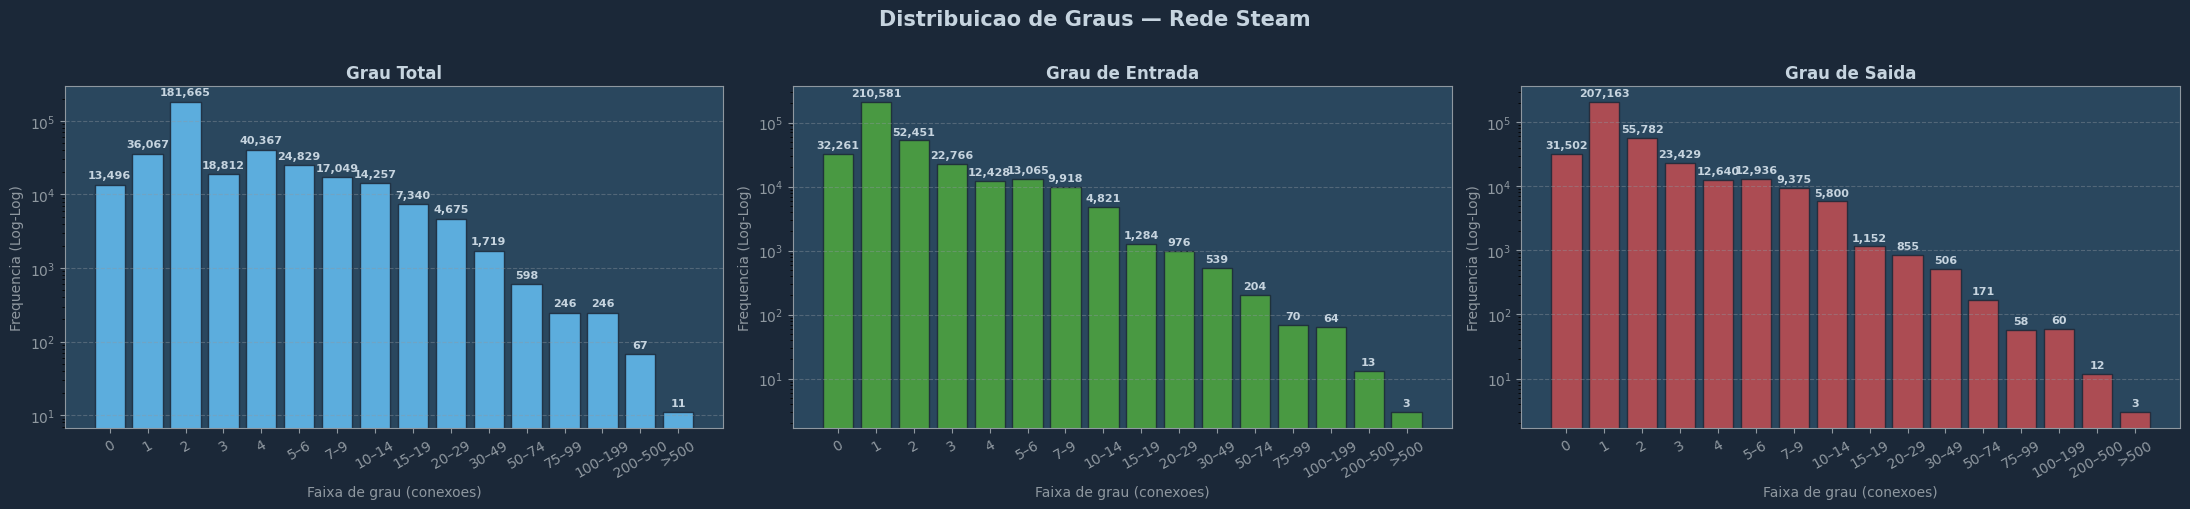

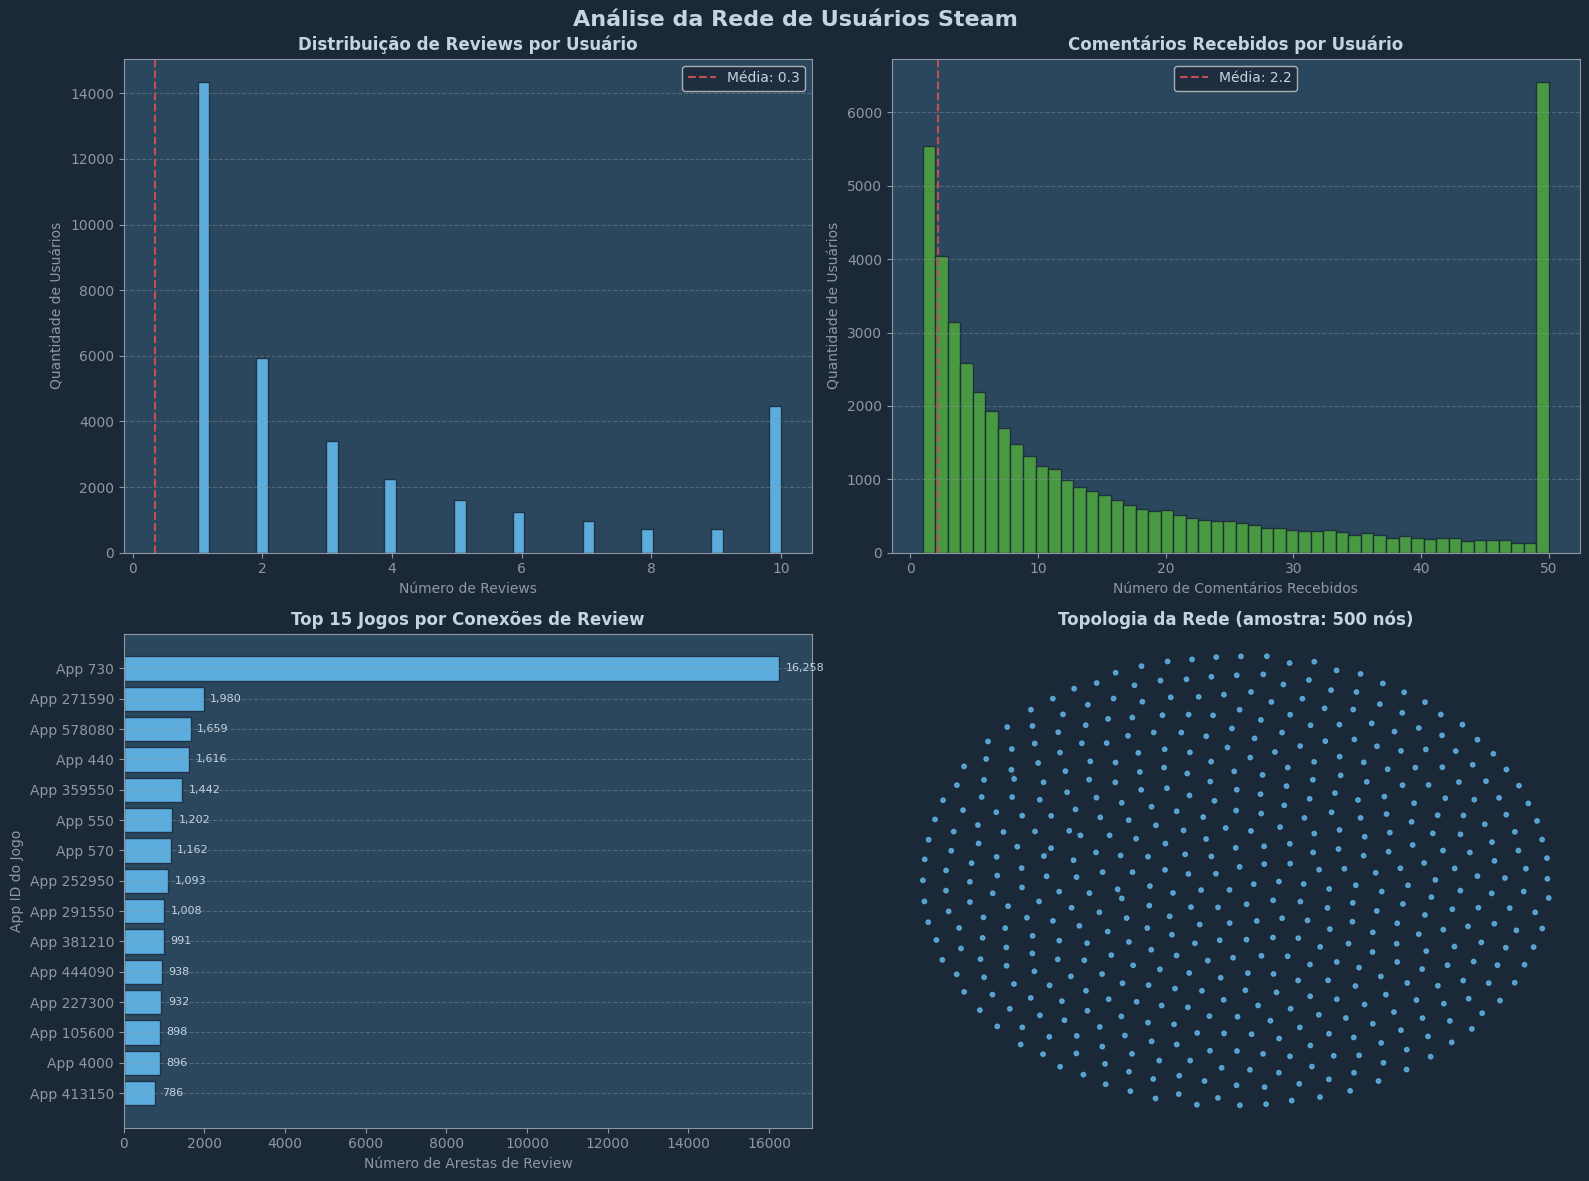

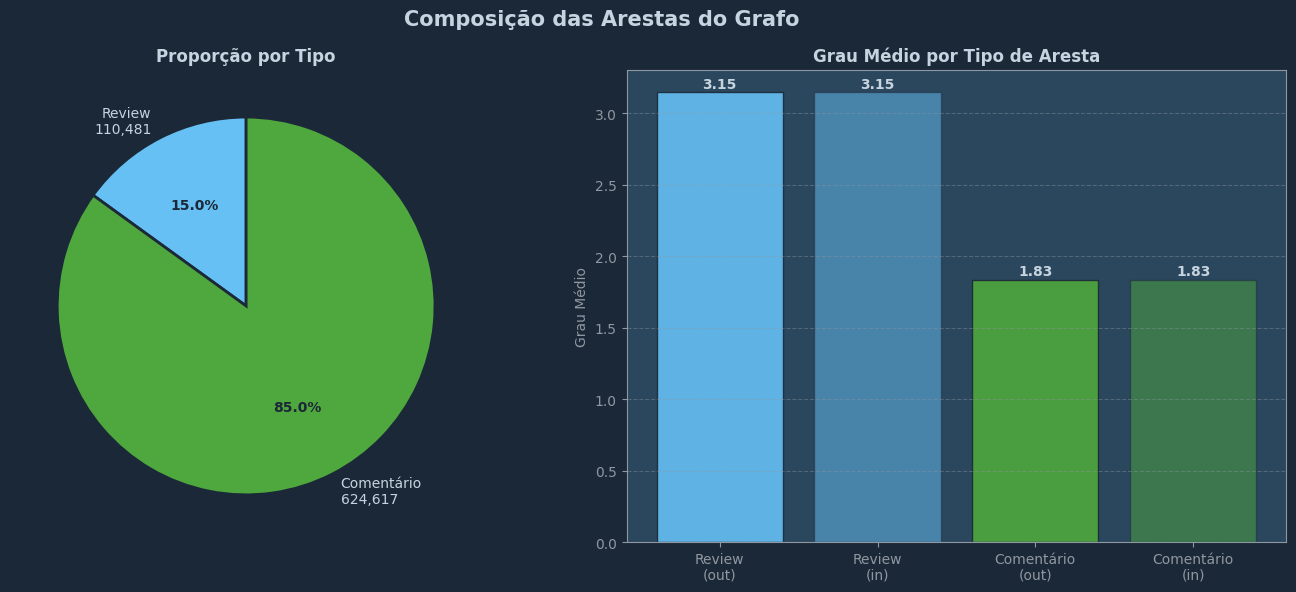

In [6]:
# Carrega o grafo completo (dirigido, todos os tipos de aresta)
G = carregar_grafo(
    nodes_path="../dataset/reviews-comment-graph-v2/nodes.json",
    edges_path="../dataset/reviews-comment-graph-v2/edges.json",
    directed=True,
)

# Estatísticas e histograma de graus
analisar_estatisticas_grafo(G)

# Painéis de análise extra
plotar_analises_extras(G, amostra_grafo=500)

# Distribuição por tipo de aresta
plotar_distribuicao_tipos(G)


  ANÁLISE DE COMPONENTES CONEXAS

Calculando WCC... 16,150 encontrados.
Calculando SCC (pode demorar em grafos grandes)... 73,453 encontrados.

[FRACO]  Componentes fracamente conectados : 16,150
[FORTE]  Componentes fortemente conectados: 73,453

  Maior WCC → 340,767 nós (94.3%)
  Maior SCC → 286,417 nós (79.2%)

  [WCC] Distribuição de tamanhos:
    Singletons  (=1)       :   13,496
    Pequenos    (2–10)     :    2,649
    Médios      (11–1000)  :        4
    Grandes     (>1000)    :        1

  [SCC] Distribuição de tamanhos:
    Singletons  (=1)       :   72,596
    Pequenos    (2–10)     :      847
    Médios      (11–1000)  :        9
    Grandes     (>1000)    :        1

--- TOP 10 MAIORES COMPONENTES (WCC) ---
  Rank         Nós    Arestas    Densidade  Grau méd.
  ----------------------------------------------------
  1        340,767    730,406     0.000006       4.29
  2             30         30     0.034483       2.00
  3             21         33     0.078571       3

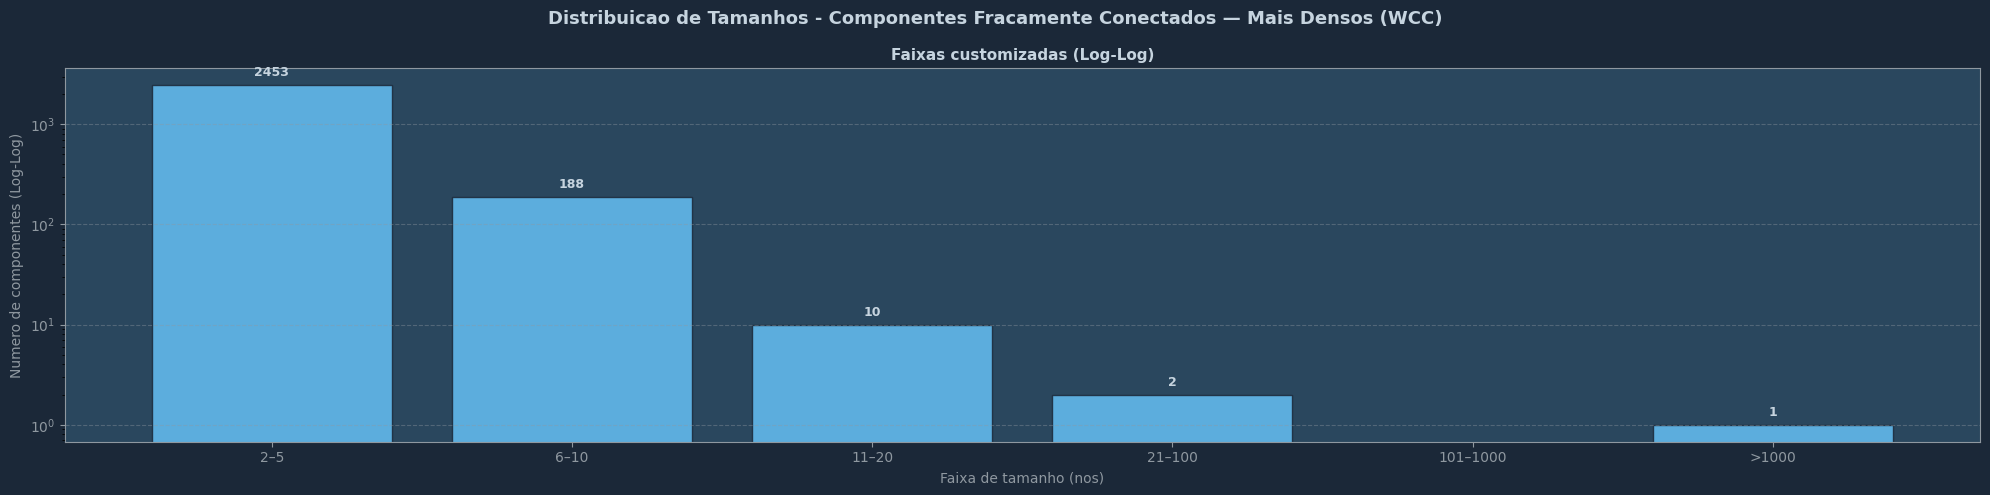


--- TOP 10 MAIORES COMPONENTES (SCC) ---
  Rank         Nós    Arestas    Densidade  Grau méd.
  ----------------------------------------------------
  1        286,417    673,614     0.000008       4.70
  2             13         13     0.083333       2.00
  3             13         15     0.096154       2.31
  4             13         13     0.083333       2.00
  5             13         14     0.089744       2.15
  6             13         24     0.153846       3.69
  7             11         19     0.172727       3.45
  8             11         12     0.109091       2.18
  9             11         15     0.136364       2.73
  10            11         11     0.100000       2.00
  [1] Salvo: ./components/componente_scc_1.html (8 nos, 17 arestas, dens=0.3036)
  [2] Salvo: ./components/componente_scc_2.html (9 nos, 17 arestas, dens=0.2361)
  [3] Salvo: ./components/componente_scc_3.html (9 nos, 17 arestas, dens=0.2361)
  [4] Salvo: ./components/componente_scc_4.html (10 nos, 21 aresta

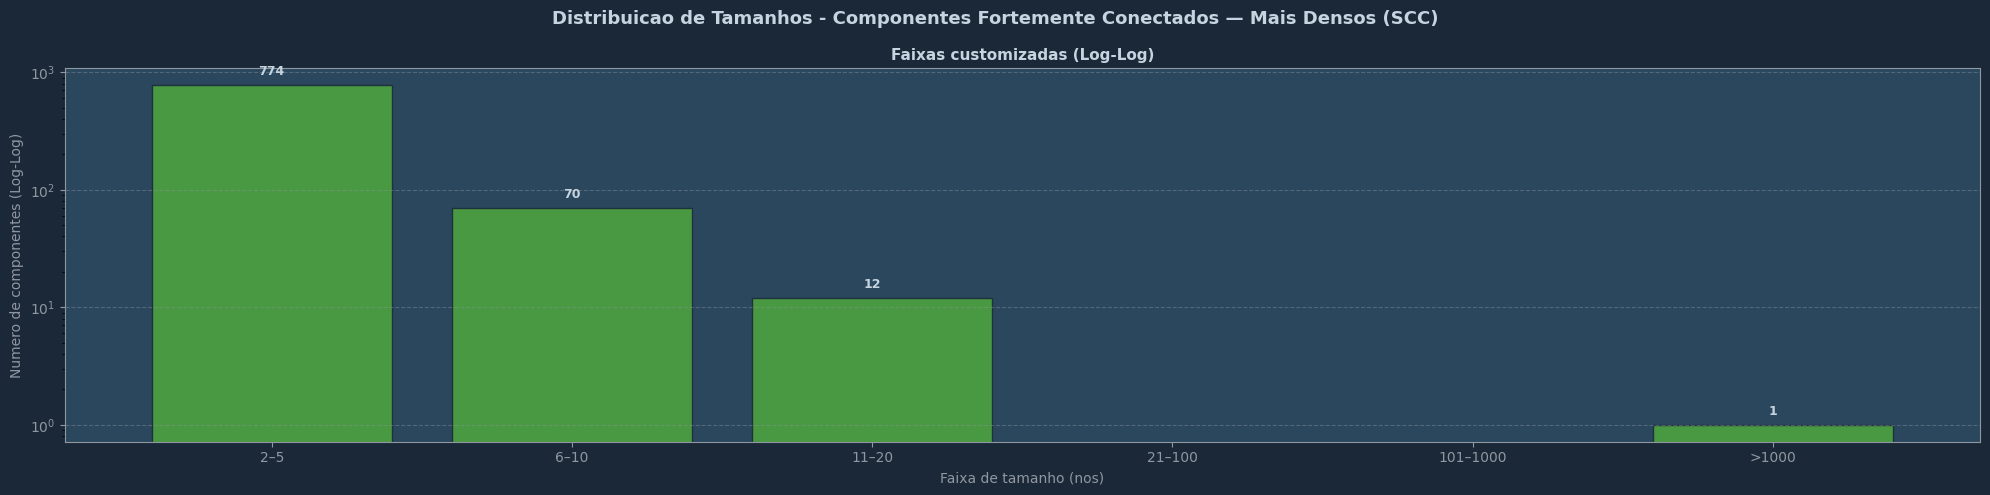

In [7]:
# Se quiser visualizar mais componentes individuais
analisar_componentes_conexas(G, max_visualizar=12)

Carregando grafo de '../graphs/graph_imed.graphml' ...
  361,444 nós | 735,098 arestas
  Grafo dirigido pronto.


  ESTATÍSTICAS GERAIS DO GRAFO
Total de nós   (usuários):      361,444
Total de arestas (conexões):    735,098

Grau médio de entrada:  2.03
Grau médio de saída:    2.03
Grau total médio:       4.07
Grau máximo (total):    3258

Densidade da rede: 0.00000563
Componentes fracamente conectados: 16,150
Coef. de agrupamento médio (amostra 5k nós): 0.044290

--- TOP 10 NÓS MAIS CONECTADOS (grau total) ---
  ID: Linger                 | Grau:   3258 | Reviews:    0 | Comentários recebidos:    0
  ID: .                      | Grau:   1916 | Reviews:    0 | Comentários recebidos:    0
  ID: Lei                    | Grau:   1620 | Reviews:    0 | Comentários recebidos:    0
  ID: Dongong                | Grau:    925 | Reviews:    0 | Comentários recebidos:    0
  ID: ! ⁧⁧ Cardoso           | Grau:    761 | Reviews:    0 | Comentários recebidos:    0
  ID: Codaxy                 | G

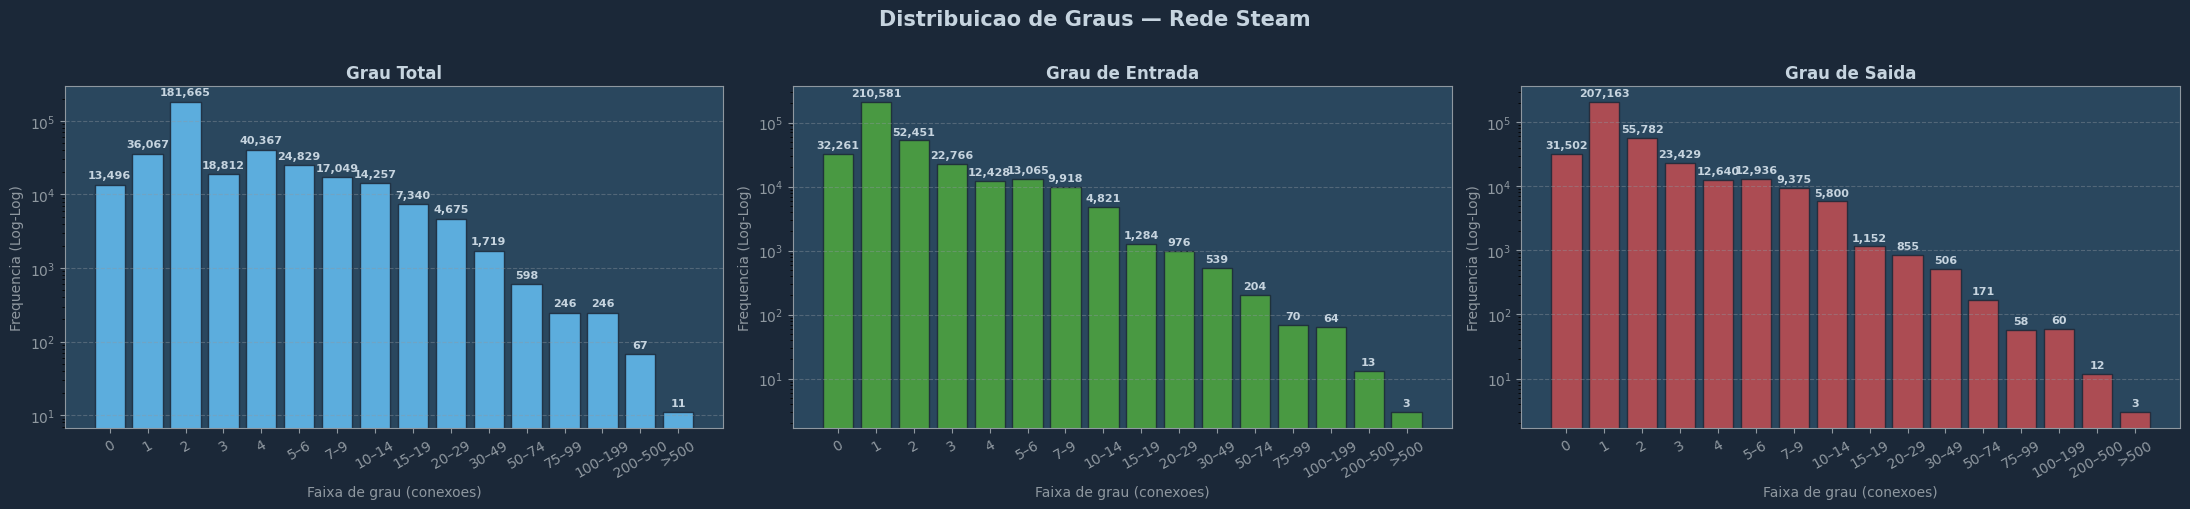

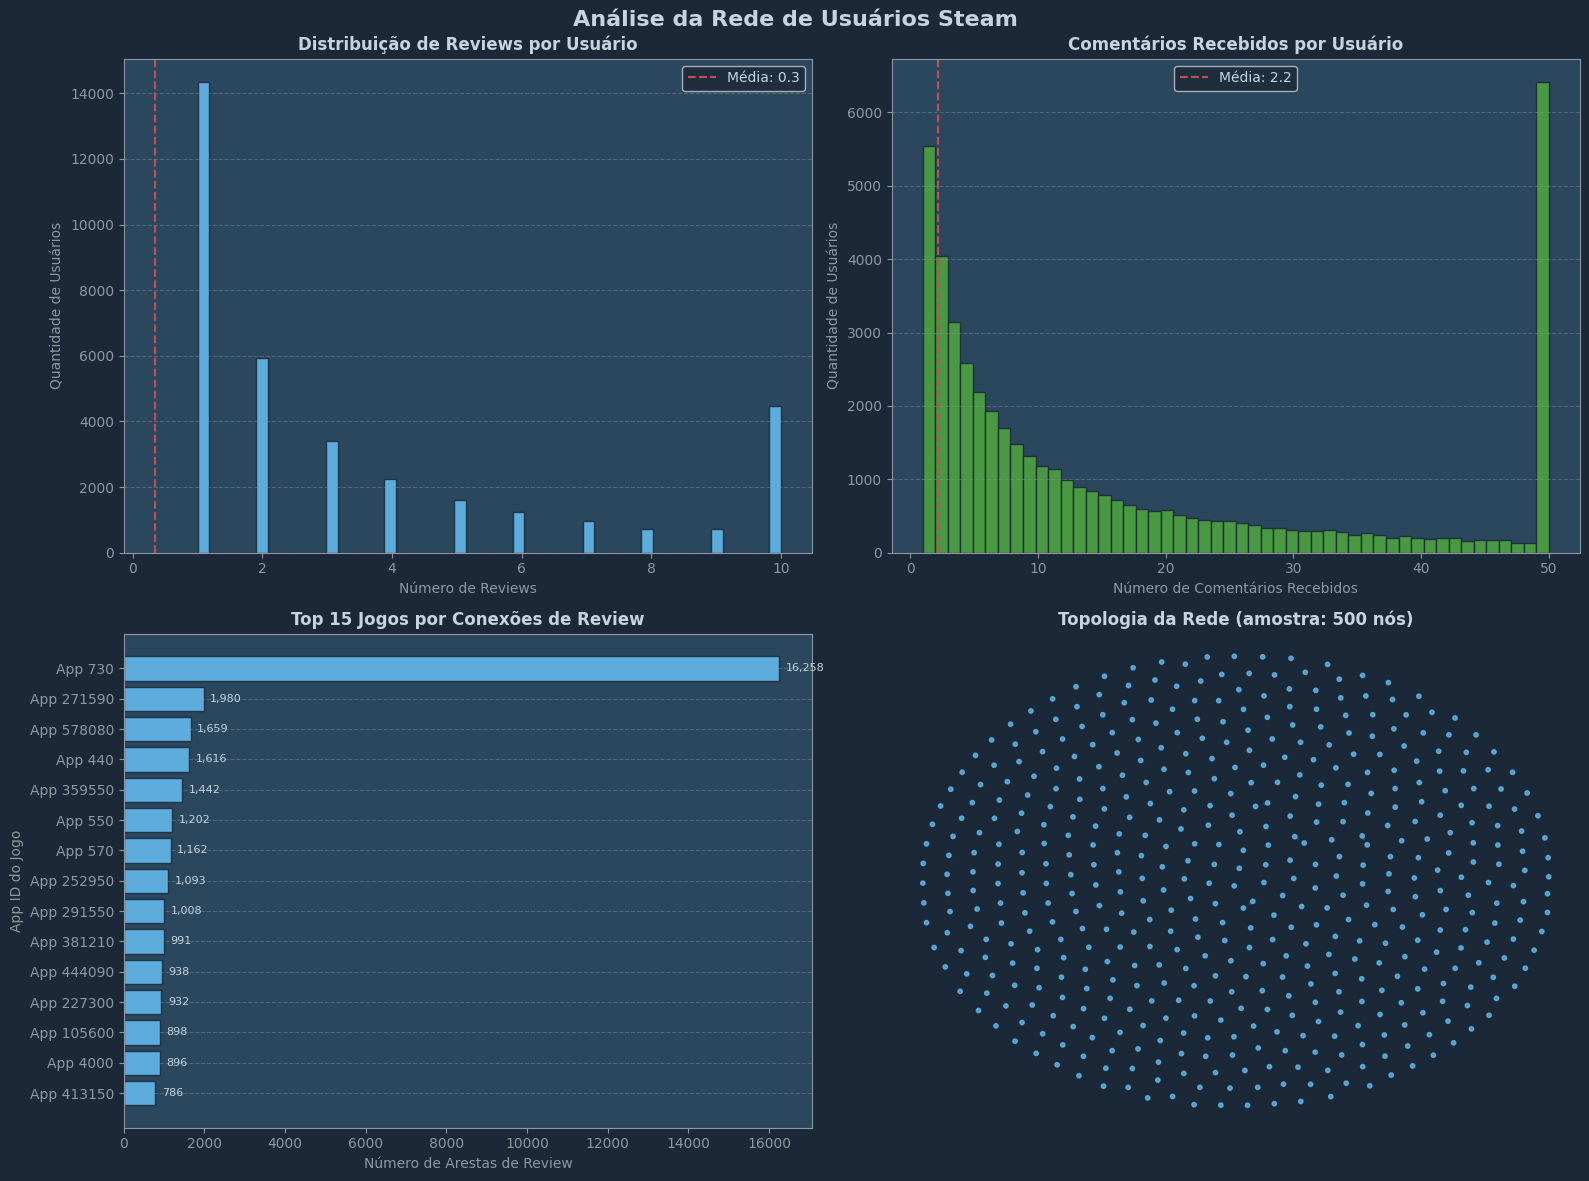

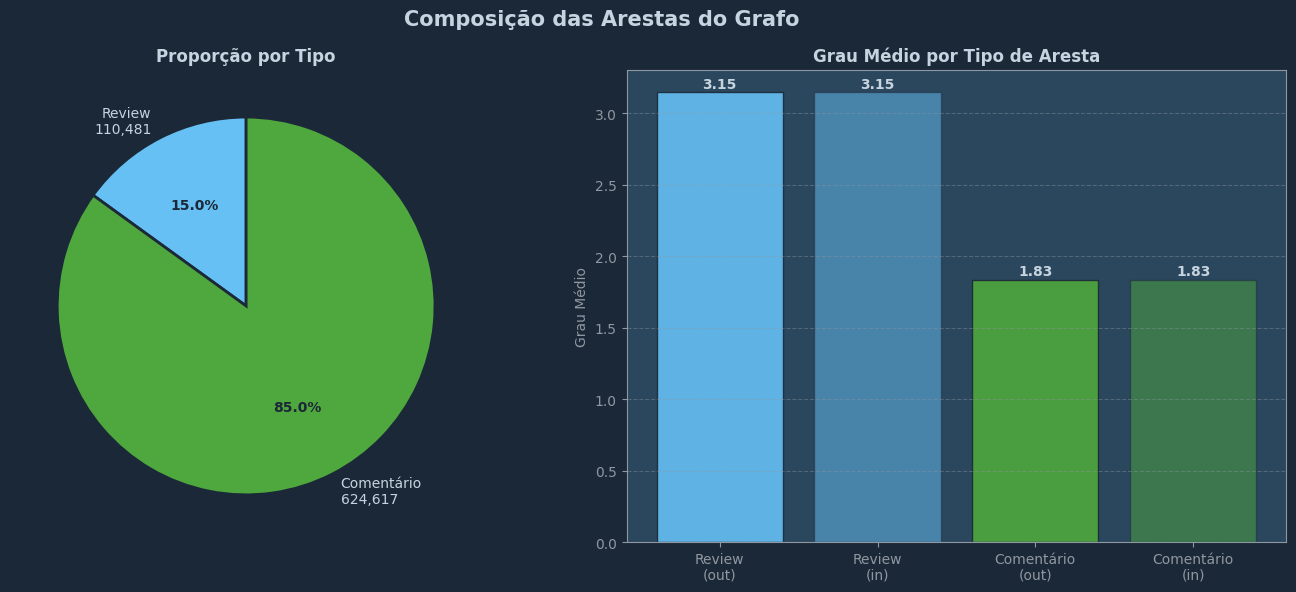

In [11]:
# Carrega o grafo completo (dirigido, todos os tipos de aresta)
G = carregar_grafo_ml(
    graph_path="../graphs/graph_imed.graphml",
    directed=True,
)

# Estatísticas e histograma de graus
analisar_estatisticas_grafo(G)

# Painéis de análise extra
plotar_analises_extras(G, amostra_grafo=500)

# Distribuição por tipo de aresta
plotar_distribuicao_tipos(G)

## Grafo Maior

Carregando nós de '../dataset/reviews-comment-graph-v3/nodes.json' ...
  67,390 nós adicionados.
Carregando arestas de '../dataset/reviews-comment-graph-v3/edges.json' ...
  1,889,686 arestas adicionadas.
  Grafo dirigido pronto.


  ESTATÍSTICAS GERAIS DO GRAFO
Total de nós   (usuários):      361,444
Total de arestas (conexões):  1,875,259

Grau médio de entrada:  5.19
Grau médio de saída:    5.19
Grau total médio:       10.38
Grau máximo (total):    8604

Densidade da rede: 0.00001435
Componentes fracamente conectados: 16,150
Coef. de agrupamento médio (amostra 5k nós): 0.523299

--- TOP 10 NÓS MAIS CONECTADOS (grau total) ---
  ID: Linger                 | Grau:   8604 | Reviews:    0 | Comentários recebidos:    0
  ID: .                      | Grau:   4785 | Reviews:    0 | Comentários recebidos:    0
  ID: Lei                    | Grau:   4385 | Reviews:    0 | Comentários recebidos:    0
  ID: Dongong                | Grau:   2495 | Reviews:    0 | Comentários recebidos:    0
  I

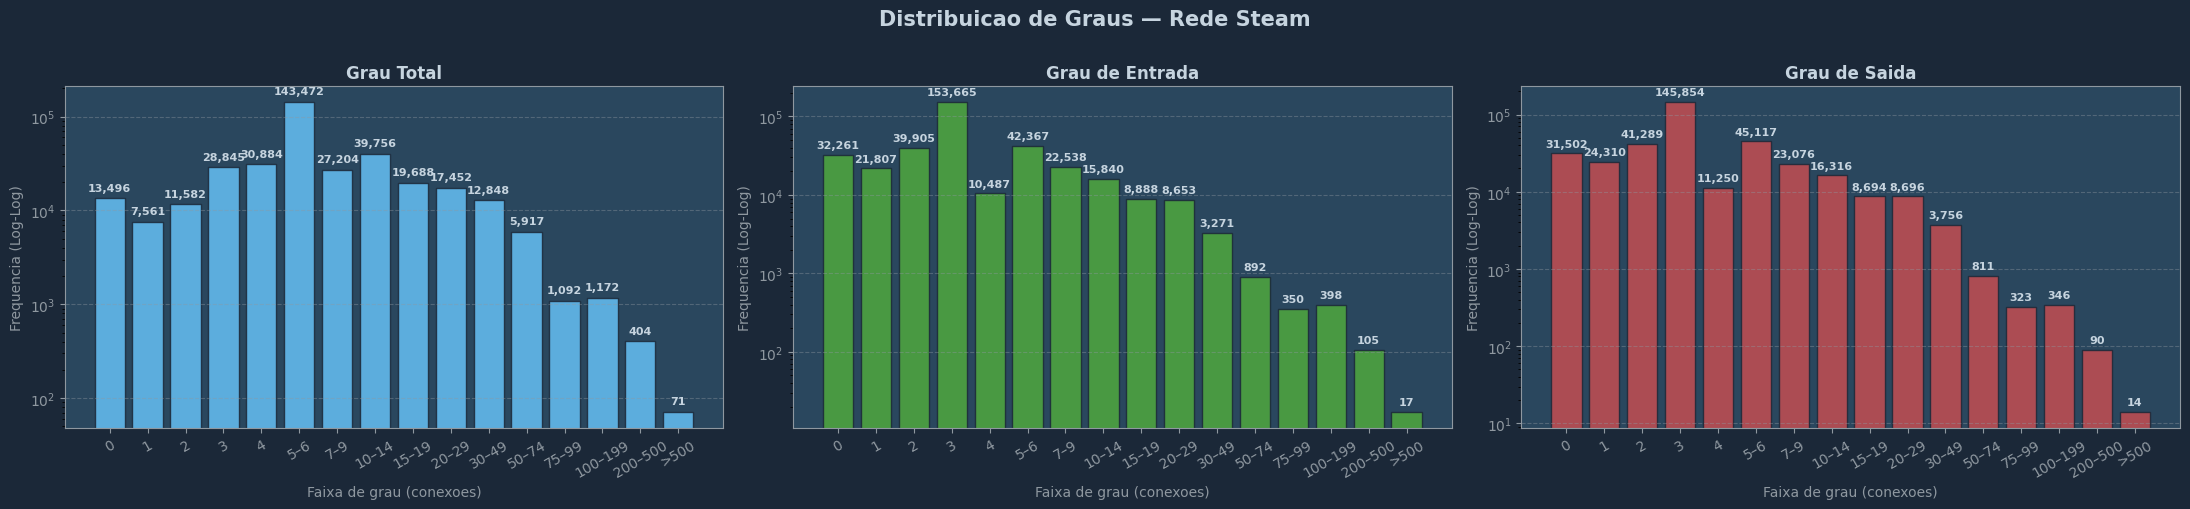

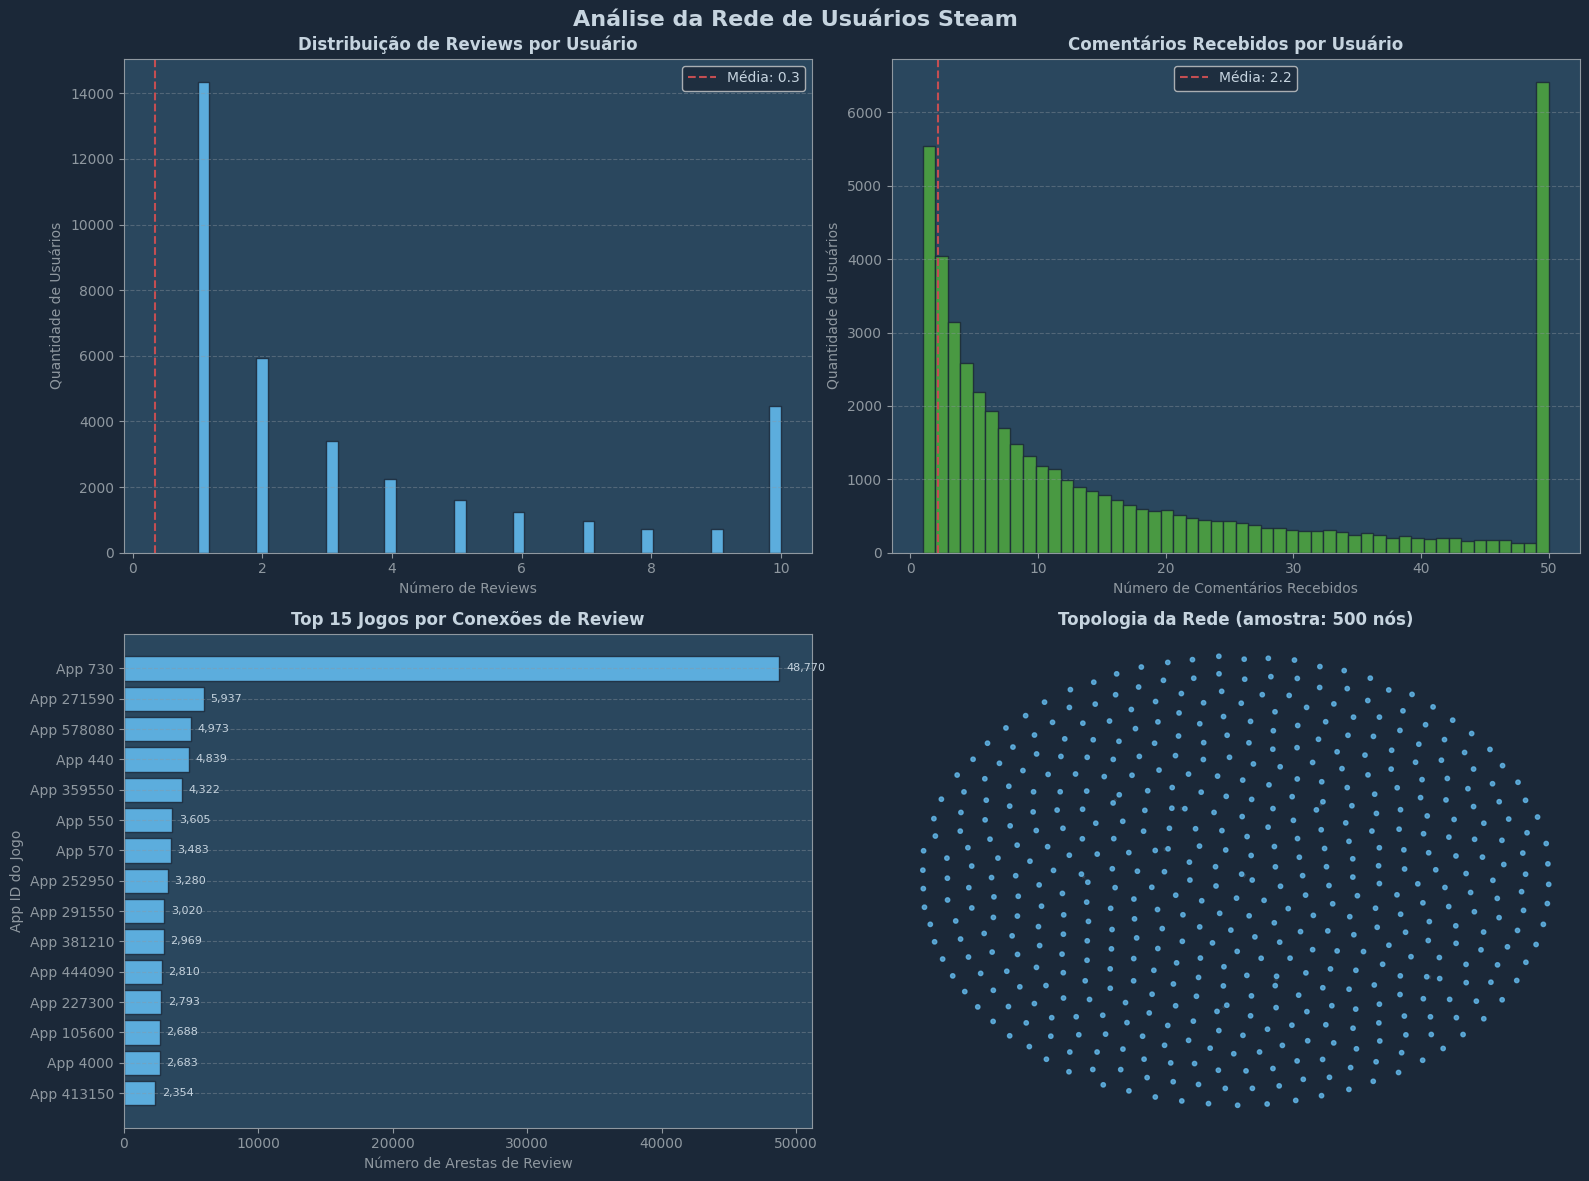

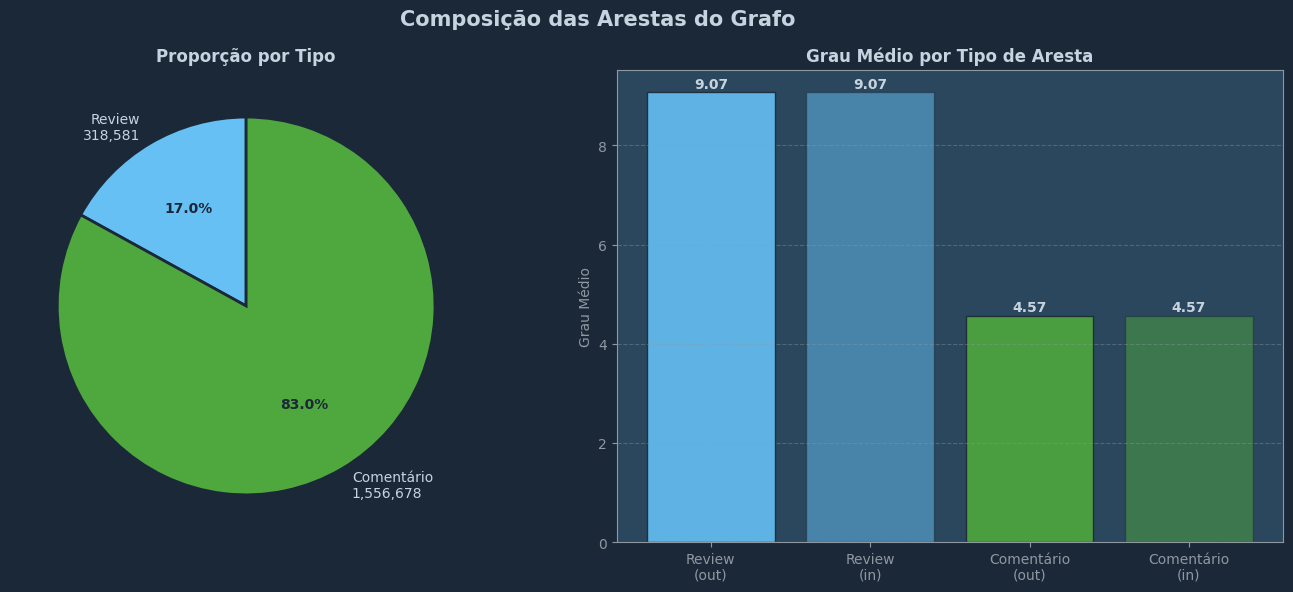

In [6]:
# Carrega o grafo completo (dirigido, todos os tipos de aresta)
G_big = carregar_grafo(
    nodes_path="../dataset/reviews-comment-graph-v3/nodes.json",
    edges_path="../dataset/reviews-comment-graph-v3/edges.json",
    directed=True,
)

# Estatísticas e histograma de graus
analisar_estatisticas_grafo(G_big)

# Painéis de análise extra
plotar_analises_extras(G_big, amostra_grafo=500)

# Distribuição por tipo de aresta
plotar_distribuicao_tipos(G_big)

Carregando grafo de '../graphs/graph_past3.graphml' ...
  361,444 nós | 1,875,259 arestas
  Grafo dirigido pronto.


  ESTATÍSTICAS GERAIS DO GRAFO
Total de nós   (usuários):      361,444
Total de arestas (conexões):  1,875,259

Grau médio de entrada:  5.19
Grau médio de saída:    5.19
Grau total médio:       10.38
Grau máximo (total):    8604

Densidade da rede: 0.00001435
Componentes fracamente conectados: 16,150
Coef. de agrupamento médio (amostra 5k nós): 0.520748

--- TOP 10 NÓS MAIS CONECTADOS (grau total) ---
  ID: Linger                 | Grau:   8604 | Reviews:    0 | Comentários recebidos:    0
  ID: .                      | Grau:   4785 | Reviews:    0 | Comentários recebidos:    0
  ID: Lei                    | Grau:   4385 | Reviews:    0 | Comentários recebidos:    0
  ID: Dongong                | Grau:   2495 | Reviews:    0 | Comentários recebidos:    0
  ID: ! ⁧⁧ Cardoso           | Grau:   1625 | Reviews:    0 | Comentários recebidos:    0
  ID: 󠀡󠀡                    

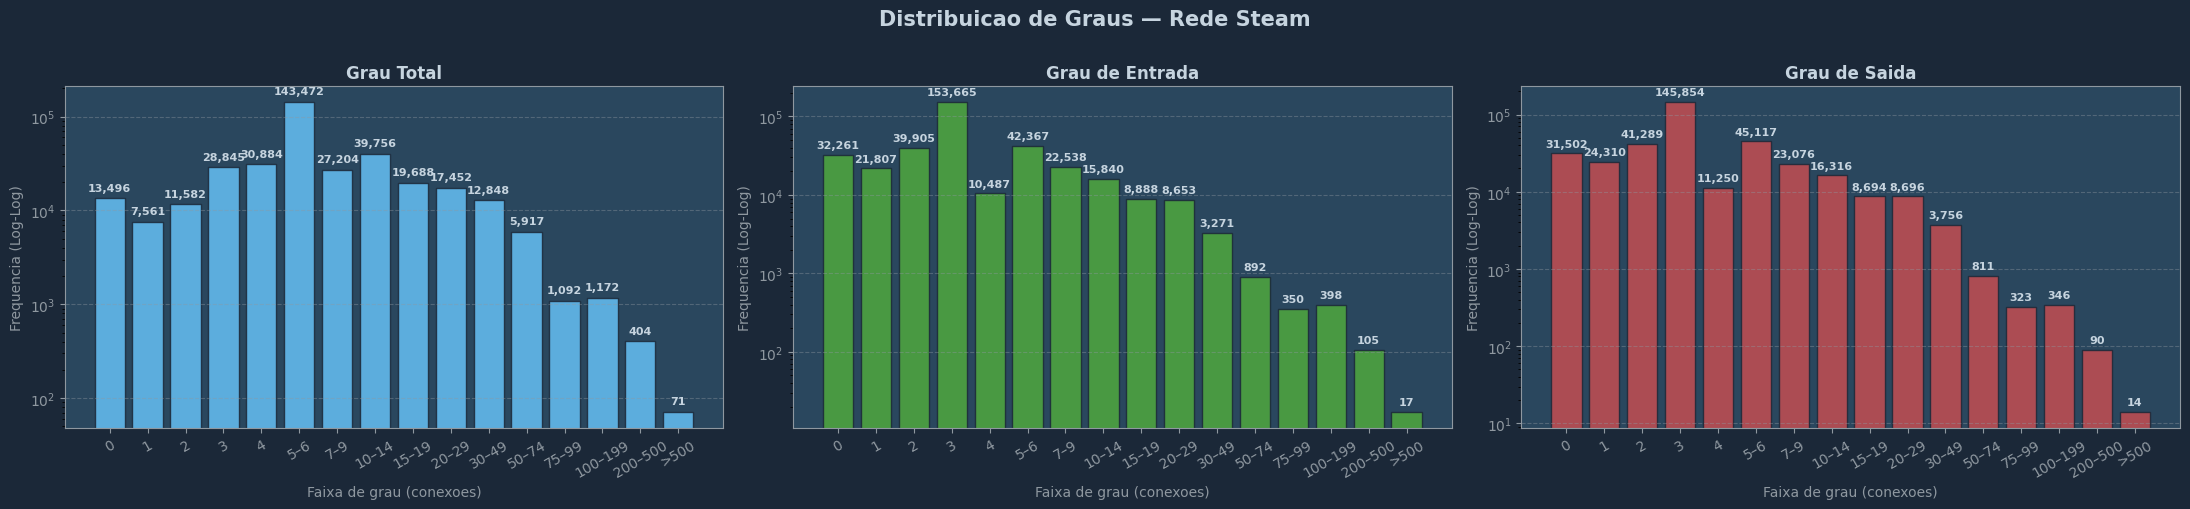

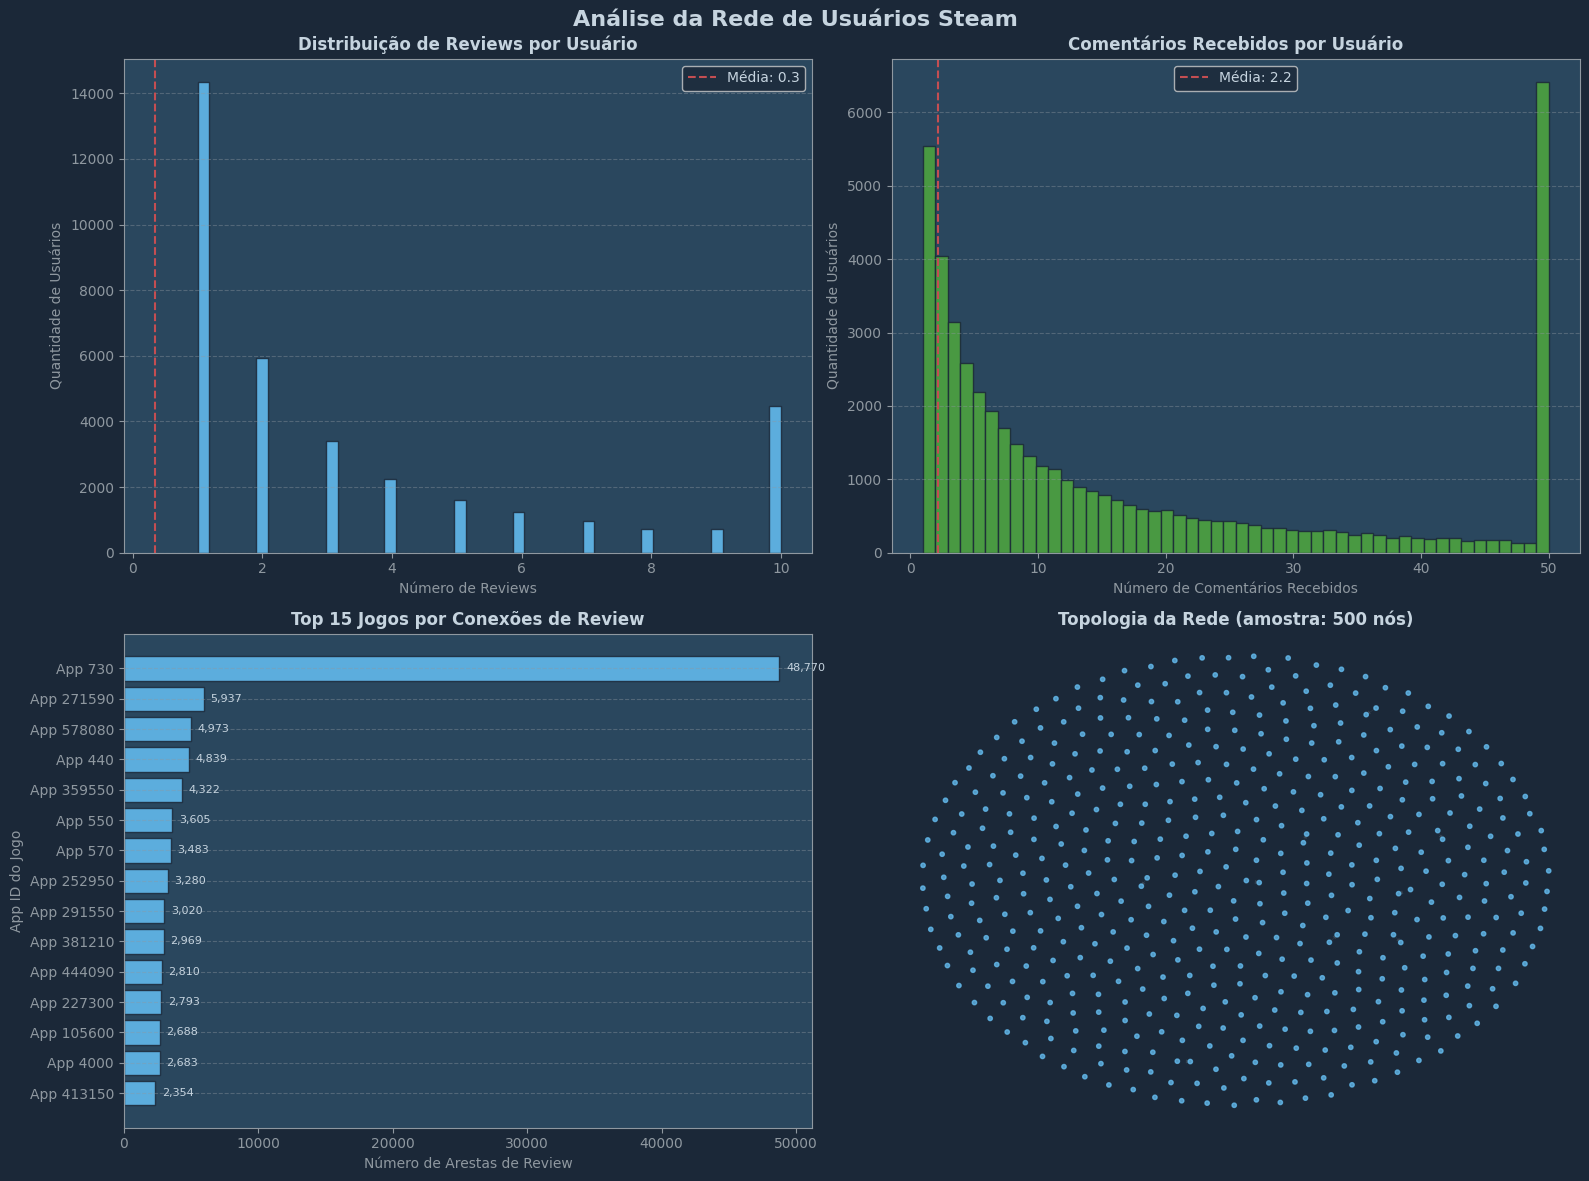

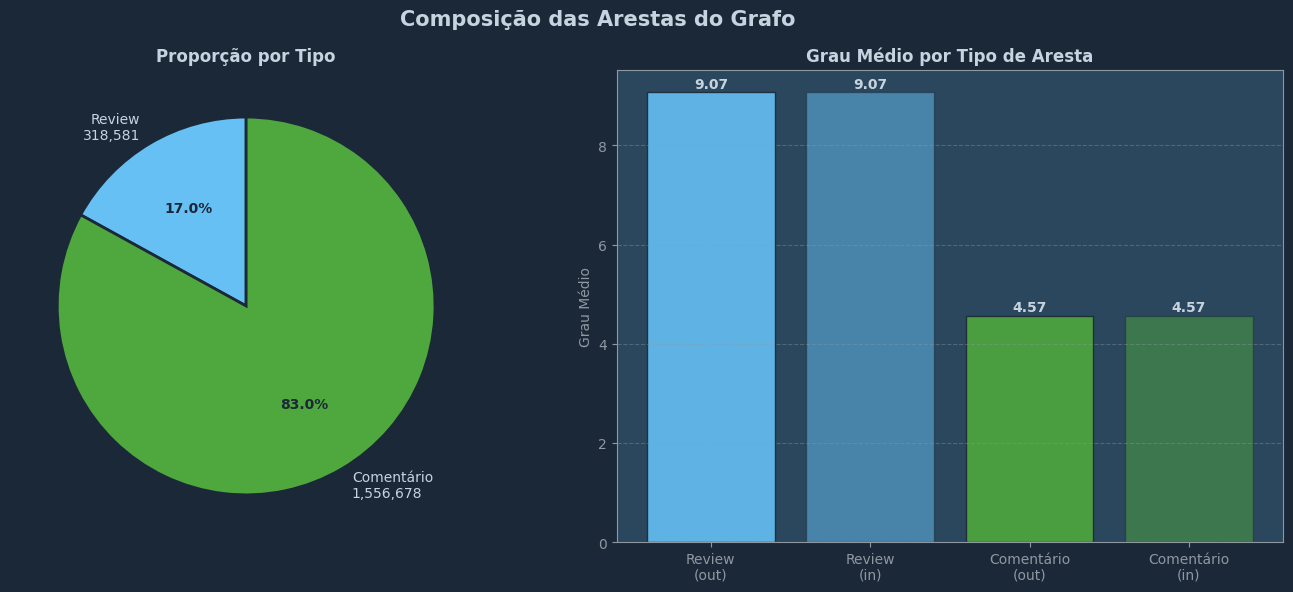

In [7]:
# Carrega o grafo completo (dirigido, todos os tipos de aresta)
G = carregar_grafo_ml(
    graph_path="../graphs/graph_past3.graphml",
    directed=True,
)

# Estatísticas e histograma de graus
analisar_estatisticas_grafo(G)

# Painéis de análise extra
plotar_analises_extras(G, amostra_grafo=500)

# Distribuição por tipo de aresta
plotar_distribuicao_tipos(G)


  ANÁLISE DE COMPONENTES CONEXAS

Calculando WCC... 16,150 encontrados.
Calculando SCC (pode demorar em grafos grandes)... 73,453 encontrados.

[FRACO]  Componentes fracamente conectados : 16,150
[FORTE]  Componentes fortemente conectados: 73,453

  Maior WCC → 340,767 nós (94.3%)
  Maior SCC → 286,417 nós (79.2%)

  [WCC] Distribuição de tamanhos:
    Singletons  (=1)       :   13,496
    Pequenos    (2–10)     :    2,649
    Médios      (11–1000)  :        4
    Grandes     (>1000)    :        1

  [SCC] Distribuição de tamanhos:
    Singletons  (=1)       :   72,596
    Pequenos    (2–10)     :      847
    Médios      (11–1000)  :        9
    Grandes     (>1000)    :        1

--- TOP 10 MAIORES COMPONENTES (WCC) ---
  Rank         Nós    Arestas    Densidade  Grau méd.
  ----------------------------------------------------
  1        340,767  1,868,020     0.000016      10.96
  2             30         80     0.091954       5.33
  3             21         77     0.183333       7

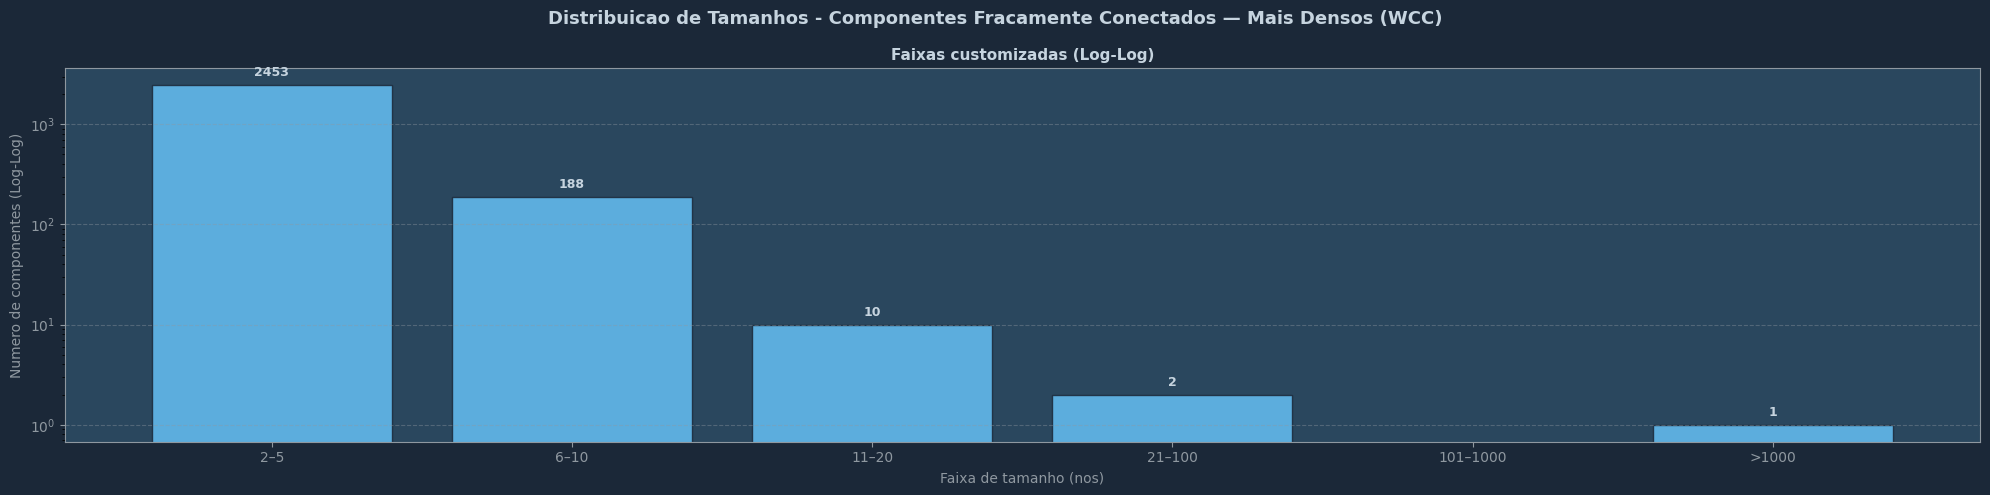


--- TOP 10 MAIORES COMPONENTES (SCC) ---
  Rank         Nós    Arestas    Densidade  Grau méd.
  ----------------------------------------------------
  1        286,417  1,728,466     0.000021      12.07
  2             13         36     0.230769       5.54
  3             13         33     0.211538       5.08
  4             13         38     0.243590       5.85
  5             13         36     0.230769       5.54
  6             13         55     0.352564       8.46
  7             11         41     0.372727       7.45
  8             11         33     0.300000       6.00
  9             11         36     0.327273       6.55
  10            11         30     0.272727       5.45
  [1] Salvo: ./components-lg/componente_scc_1.html (9 nos, 34 arestas, dens=0.4722)
  [2] Salvo: ./components-lg/componente_scc_2.html (8 nos, 25 arestas, dens=0.4464)
  [3] Salvo: ./components-lg/componente_scc_3.html (8 nos, 24 arestas, dens=0.4286)
  [4] Salvo: ./components-lg/componente_scc_4.html (8 nos

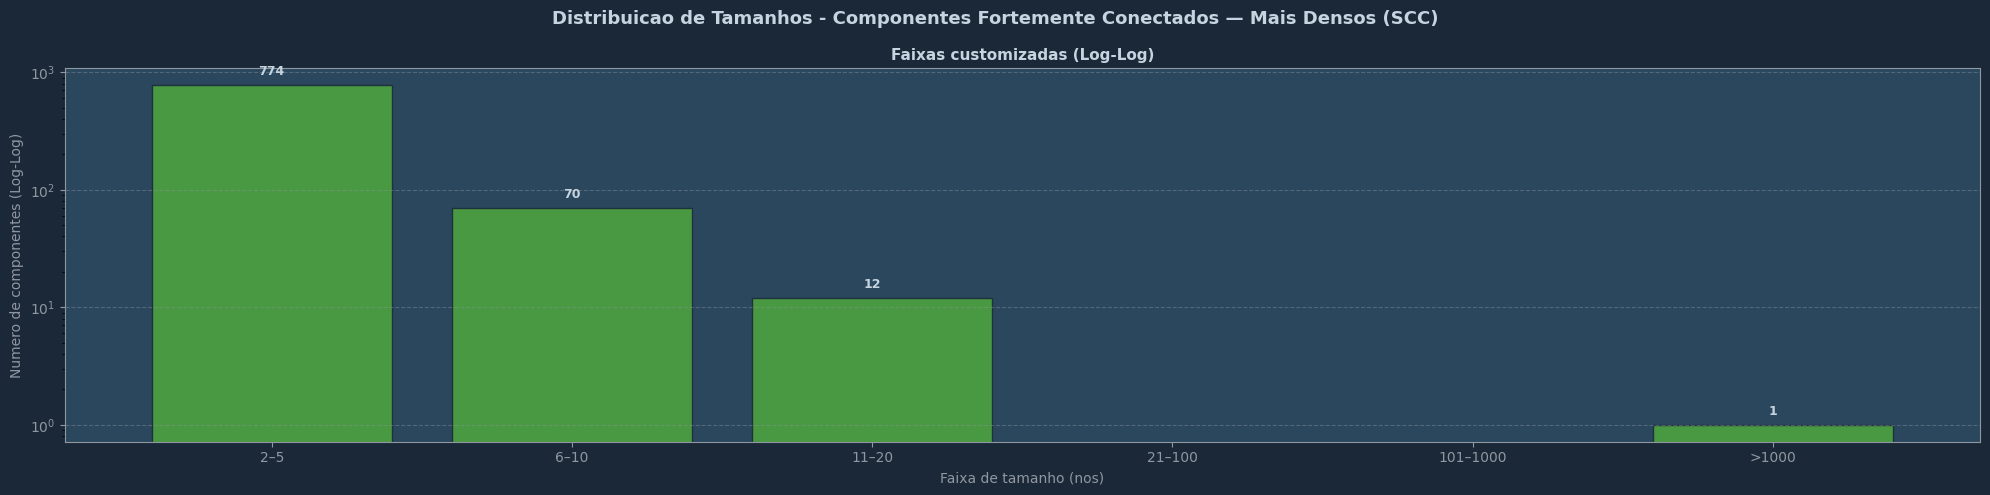

In [7]:
analisar_componentes_conexas(G_big, max_visualizar=12, path="components-lg")


  ANÁLISE DE COMPONENTES CONEXAS

Calculando WCC... 16,150 encontrados.
Calculando SCC (pode demorar em grafos grandes)... 73,453 encontrados.

[FRACO]  Componentes fracamente conectados : 16,150
[FORTE]  Componentes fortemente conectados: 73,453

  Maior WCC → 340,767 nós (94.3%)
  Maior SCC → 286,417 nós (79.2%)

  [WCC] Distribuição de tamanhos:
    Singletons  (=1)       :   13,496
    Pequenos    (2–10)     :    2,649
    Médios      (11–1000)  :        4
    Grandes     (>1000)    :        1

  [SCC] Distribuição de tamanhos:
    Singletons  (=1)       :   72,596
    Pequenos    (2–10)     :      847
    Médios      (11–1000)  :        9
    Grandes     (>1000)    :        1

--- TOP 10 MAIORES COMPONENTES (WCC) ---
  Rank         Nós    Arestas    Densidade  Grau méd.
  ----------------------------------------------------
  1        340,767  1,868,020     0.000016      10.96
  2             30         80     0.091954       5.33
  3             21         77     0.183333       7

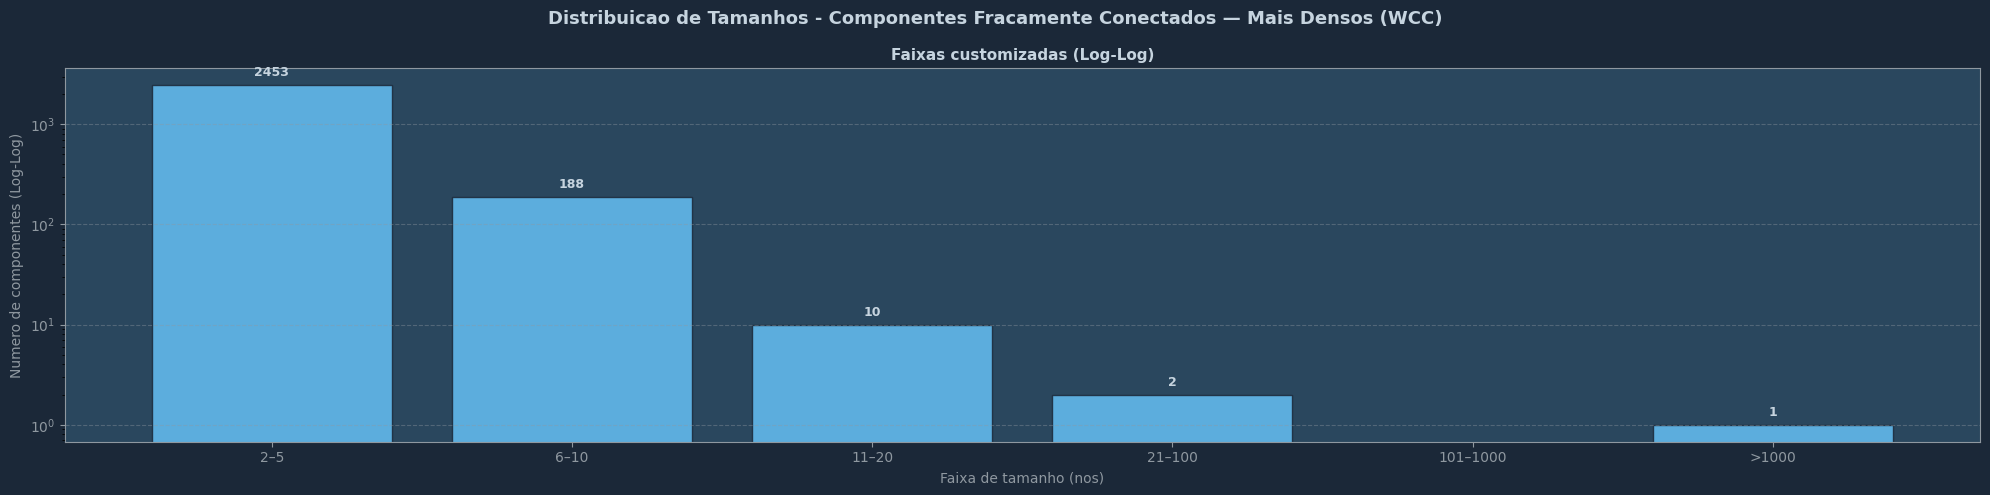


--- TOP 10 MAIORES COMPONENTES (SCC) ---
  Rank         Nós    Arestas    Densidade  Grau méd.
  ----------------------------------------------------
  1        286,417  1,728,466     0.000021      12.07
  2             13         36     0.230769       5.54
  3             13         33     0.211538       5.08
  4             13         38     0.243590       5.85
  5             13         36     0.230769       5.54
  6             13         55     0.352564       8.46
  7             11         41     0.372727       7.45
  8             11         33     0.300000       6.00
  9             11         36     0.327273       6.55
  10            11         30     0.272727       5.45
  [1] Salvo: ./components-lg/componente_scc_1.html (9 nos, 34 arestas, dens=0.4722)
  [2] Salvo: ./components-lg/componente_scc_2.html (8 nos, 25 arestas, dens=0.4464)
  [3] Salvo: ./components-lg/componente_scc_3.html (8 nos, 24 arestas, dens=0.4286)
  [4] Salvo: ./components-lg/componente_scc_4.html (8 nos

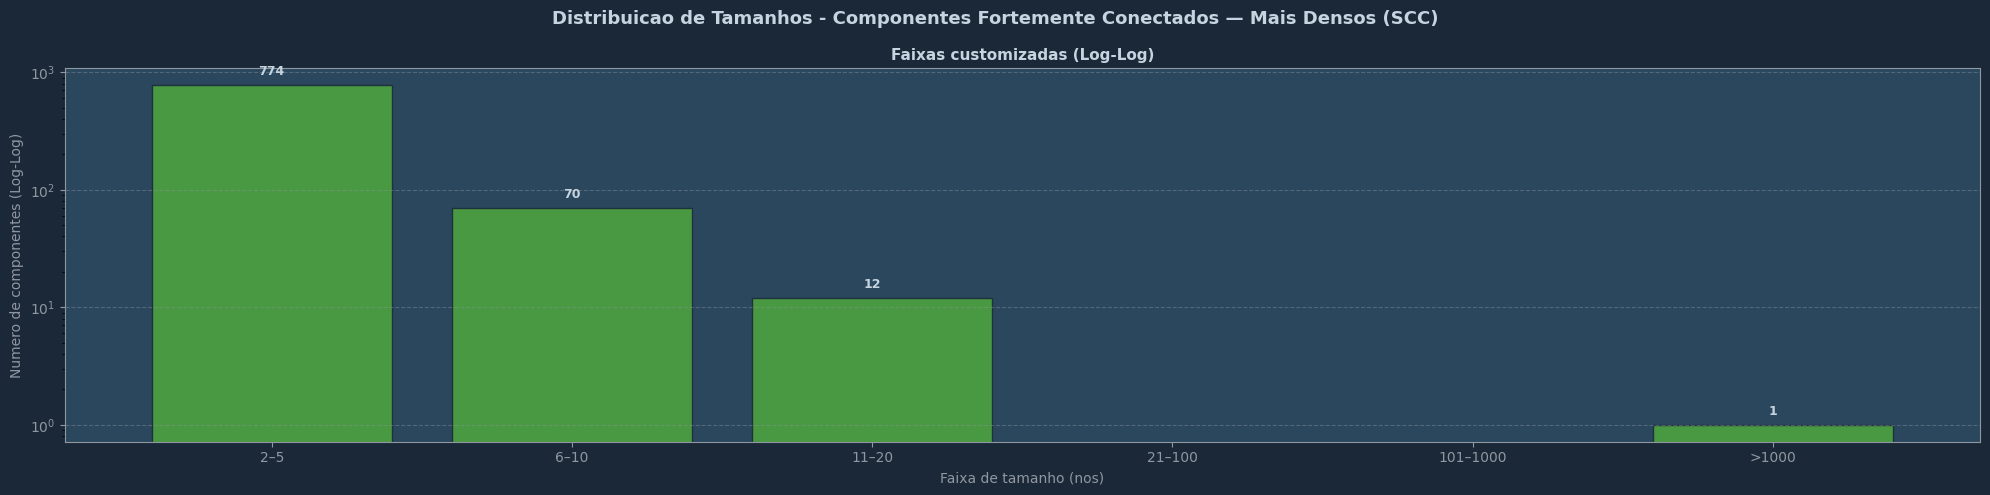

In [8]:
analisar_componentes_conexas(G, max_visualizar=12, path="components-lg")